# 📊 Instacart – Spark SQL Analysis & Visual Storytelling
> **Narrative:** *"Khách hàng Instacart mua gì, khi nào, và tại sao họ quay lại?"*
>
> 15 queries được sắp xếp thành 5 chương, dẫn dắt từ tổng quan hành vi đặt hàng
> → chi tiết giỏ hàng → hiệu suất danh mục → động lực reorder → cơ hội kinh doanh.

---
## ⚙️ Setup – Style & Helpers


In [1]:
# Cài đặt PySpark trên Kaggle (chạy 1 lần)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'pyspark', 'findspark', '-q'],
               capture_output=True)
print('✅ pyspark & findspark ready')

✅ pyspark & findspark ready


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns

print('✅ Imports OK')


✅ Imports OK


In [3]:
spark = (
    SparkSession.builder
    .appName('Instacart_BigData_Analysis')
    .master('local[*]')                              # Kaggle: 2 CPU
    .config('spark.driver.memory', '8g')
    .config('spark.executor.memory', '4g')
    .config('spark.sql.shuffle.partitions', '8')     # giảm overhead cho local
    .config('spark.default.parallelism', '4')
    .config('spark.sql.adaptive.enabled', 'true')    # AQE
    .config('spark.sql.adaptive.coalescePartitions.enabled', 'true')
    .config('spark.ui.showConsoleProgress', 'false')  # tắt spam log
    .config('spark.driver.extraJavaOptions',
            '-Dlog4j.rootCategory=ERROR,console')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('ERROR')   # ẩn WARN

print('✅ SparkSession khởi tạo thành công!')
print(f'   Version : {spark.version}')
print(f'   App     : {spark.sparkContext.appName}')
print(f'   Master  : {spark.sparkContext.master}')


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/13 04:50:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ SparkSession khởi tạo thành công!
   Version : 4.0.2
   App     : Instacart_BigData_Analysis
   Master  : local[*]


In [6]:
from pyspark.sql.types import IntegerType, DoubleType
import pyspark.sql.functions as F

BASE = '/kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset'

# ── Tùy chọn đọc CSV ─────────────────────────────────────────────────────
csv_options = {
    "header": "true",
    "inferSchema": "true",
    "quote": '"',       # dấu bao chuỗi
    "escape": '"',      # escape bằng chính dấu quote (chuẩn RFC 4180)
    "multiLine": "true" # xử lý trường hợp newline bên trong chuỗi
}

orders_df = (
    spark.read.options(**csv_options).csv(f'{BASE}/orders.csv')
    .withColumnRenamed('days_since_prior_order', 'days_since_prior')
)

order_products_prior_df = spark.read.options(**csv_options).csv(f'{BASE}/order_products__prior.csv')
order_products_train_df = spark.read.options(**csv_options).csv(f'{BASE}/order_products__train.csv')

# ── products.csv: dùng schema tường minh, KHÔNG inferSchema ──────────────
from pyspark.sql.types import StructType, StructField, IntegerType, StringType

products_schema = StructType([
    StructField("product_id",   IntegerType(), True),
    StructField("product_name", StringType(),  True),
    StructField("aisle_id",     IntegerType(), True),
    StructField("department_id",IntegerType(), True),
])

products_df = spark.read.options(
    header="true",
    quote='"',
    escape='"',
    multiLine="true"
).schema(products_schema).csv(f'{BASE}/products.csv')

aisles_df       = spark.read.options(**csv_options).csv(f'{BASE}/aisles.csv')
departments_df  = spark.read.options(**csv_options).csv(f'{BASE}/departments.csv')

# ── Cast kiểu dữ liệu ────────────────────────────────────────────────────
orders_df = (
    orders_df
    .withColumn("days_since_prior",   F.col("days_since_prior").cast(DoubleType()))
    .withColumn("order_dow",          F.col("order_dow").cast(DoubleType()))
    .withColumn("order_hour_of_day",  F.col("order_hour_of_day").cast(DoubleType()))
)

aisles_df      = aisles_df.withColumn("aisle_id",      F.col("aisle_id").cast(IntegerType()))
departments_df = departments_df.withColumn("department_id", F.col("department_id").cast(IntegerType()))

# ── Gộp prior + train ─────────────────────────────────────────────────────
order_products_all_df = order_products_prior_df.union(order_products_train_df)

# ── Đăng ký TempViews ─────────────────────────────────────────────────────
orders_df.createOrReplaceTempView("orders")
order_products_prior_df.createOrReplaceTempView("order_products_prior")
order_products_train_df.createOrReplaceTempView("order_products_train")
order_products_all_df.createOrReplaceTempView("order_products_all")
products_df.createOrReplaceTempView("products")
aisles_df.createOrReplaceTempView("aisles")
departments_df.createOrReplaceTempView("departments")

print('✅ Đọc xong và đăng ký TempViews!')

# Kiểm tra nhanh
products_df.show(3, truncate=False)
print("products schema:"); products_df.printSchema()

✅ Đọc xong và đăng ký TempViews!
+----------+------------------------------------+--------+-------------+
|product_id|product_name                        |aisle_id|department_id|
+----------+------------------------------------+--------+-------------+
|1         |Chocolate Sandwich Cookies          |61      |19           |
|2         |All-Seasons Salt                    |104     |13           |
|3         |Robust Golden Unsweetened Oolong Tea|94      |7            |
+----------+------------------------------------+--------+-------------+
only showing top 3 rows
products schema:
root
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- aisle_id: integer (nullable = true)
 |-- department_id: integer (nullable = true)



In [7]:
orders_df.createOrReplaceTempView('orders')
order_products_prior_df.createOrReplaceTempView('order_products_prior')
order_products_train_df.createOrReplaceTempView('order_products_train')
order_products_all_df.createOrReplaceTempView('order_products_all')
products_df.createOrReplaceTempView('products')
aisles_df.createOrReplaceTempView('aisles')
departments_df.createOrReplaceTempView('departments')

print('✅ TempViews đã tạo:')
for v in spark.catalog.listTables():
    print(f'   → {v.name}')

✅ TempViews đã tạo:
   → aisles
   → departments
   → order_products_all
   → order_products_prior
   → order_products_train
   → orders
   → products


In [8]:
import warnings, textwrap
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# ── Global style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "font.family": "DejaVu Sans",
})

# Brand-inspired palette
C_BLUE   = "#2563EB"
C_GREEN  = "#16A34A"
C_AMBER  = "#D97706"
C_RED    = "#DC2626"
C_PURPLE = "#7C3AED"
C_TEAL   = "#0891B2"
C_GRAY   = "#6B7280"
PALETTE  = [C_BLUE, C_GREEN, C_AMBER, C_RED, C_PURPLE, C_TEAL]

def save_show(fig, name):
    fig.savefig(f"/kaggle/working/{name}.png",
                dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

def fmt_k(x, _):
    return f"{x/1e6:.1f}M" if x>=1e6 else f"{x/1e3:.0f}K" if x>=1e3 else f"{x:.0f}"

def add_bar_labels(ax, fmt="{:.0f}", fontsize=8, color="black", padding=0.5):
    for bar in ax.patches:
        w = bar.get_width()
        if w > 0:
            ax.text(w + padding, bar.get_y() + bar.get_height()/2,
                    fmt.format(w), va="center", ha="left",
                    fontsize=fontsize, color=color)

print("✅ Style & helpers ready")


✅ Style & helpers ready


---
## 📖 Chương 1 — Khi nào khách hàng mua hàng?
*Tổng quan hành vi đặt hàng theo thời gian.*


### Q1 · Heatmap đơn hàng theo Giờ × Ngày trong tuần
**Kỹ thuật:** `GROUP BY` + `CASE WHEN` + `SUM() OVER()` (Window — pct_of_total)

**Insight muốn truyền tải:** Tìm "giờ vàng" để chạy promotion — Sunday 10am là đỉnh tuyệt đối.


In [9]:
q1 = spark.sql("""
    SELECT
        CASE order_dow
            WHEN 0 THEN '0-Sun' WHEN 1 THEN '1-Mon' WHEN 2 THEN '2-Tue'
            WHEN 3 THEN '3-Wed' WHEN 4 THEN '4-Thu' WHEN 5 THEN '5-Fri'
            WHEN 6 THEN '6-Sat'
        END                                                  AS day_name,
        CAST(order_hour_of_day AS INT)                       AS hour,
        COUNT(*)                                             AS n_orders,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 4)  AS pct_total
    FROM orders
    GROUP BY order_dow, day_name, hour
    ORDER BY order_dow, hour
""").cache()

q1_pd = q1.toPandas()
q1_pd.head()


,day_name,hour,n_orders,pct_total
0,0-Sun,0,3936,0.1151
1,0-Sun,1,2398,0.0701
2,0-Sun,2,1409,0.0412
3,0-Sun,3,963,0.0281
4,0-Sun,4,813,0.0238


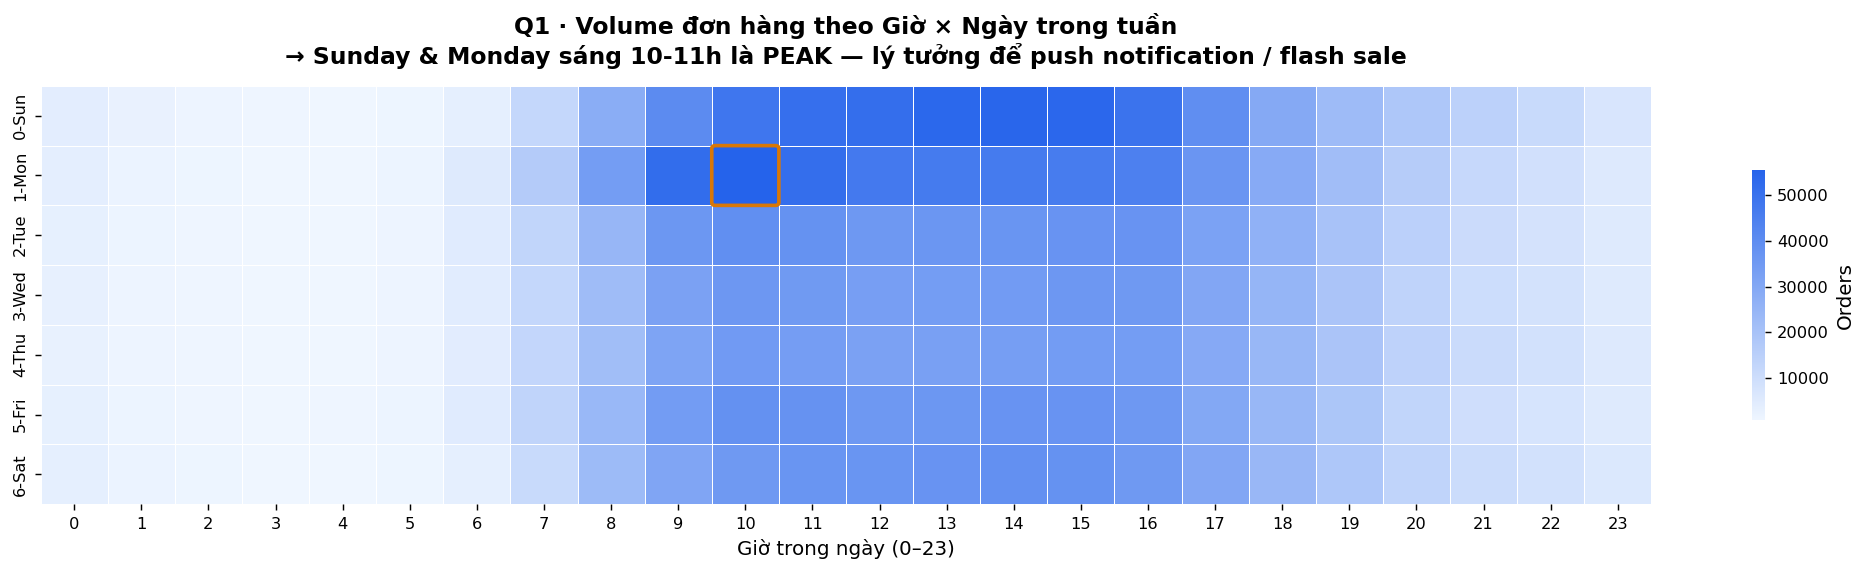

In [12]:
pivot = (q1_pd.pivot(index="day_name", columns="hour", values="n_orders")
              .sort_index())

fig, ax = plt.subplots(figsize=(16, 4.5))
cmap = LinearSegmentedColormap.from_list("insta", ["#EFF6FF", "#2563EB"])
sns.heatmap(pivot, ax=ax, cmap=cmap, linewidths=.4,
            fmt=".0f", cbar_kws={"label": "Orders", "shrink": .6})

ax.set_title("Q1 · Volume đơn hàng theo Giờ × Ngày trong tuần\n"
             "→ Sunday & Monday sáng 10-11h là PEAK — lý tưởng để push notification / flash sale",
             pad=12)
ax.set_xlabel("Giờ trong ngày (0–23)")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0)

# Annotate global peak
peak = q1_pd.loc[q1_pd["n_orders"].idxmax()]
ax.add_patch(mpatches.FancyBboxPatch(
    (peak["hour"]+0.05, list(pivot.index).index(peak["day_name"])+0.05),
    0.9, 0.9, boxstyle="round,pad=0.05",
    linewidth=2, edgecolor=C_AMBER, facecolor="none", zorder=5))

fig.tight_layout()
save_show(fig, "q1_heatmap_hour_dow")


### Q2 · Khoảng cách giữa các lần mua — phân phối & cumulative
**Kỹ thuật:** `GROUP BY` + `SUM() OVER(ORDER BY …)` (Cumulative Running Total)

**Insight:** 30% khách hàng quay lại trong ≤ 7 ngày — đây là nhóm **"weekly shoppers"** cần được ưu tiên.


In [13]:
q2 = spark.sql("""
    SELECT
        CAST(days_since_prior AS INT)                         AS gap_days,
        COUNT(*)                                              AS n_orders,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 3)   AS pct,
        SUM(COUNT(*)) OVER (ORDER BY CAST(days_since_prior AS INT)
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS cum_orders
    FROM orders
    WHERE days_since_prior IS NOT NULL
    GROUP BY gap_days
    ORDER BY gap_days
""").cache()

q2_pd = q2.toPandas()
total_orders = q2_pd["cum_orders"].max()
q2_pd["cum_pct"] = q2_pd["cum_orders"] / total_orders * 100
q2_pd.head(10)


,gap_days,n_orders,pct,cum_orders,cum_pct
0,0,67755,2.108,67755,2.107548
1,1,145247,4.518,213002,6.625516
2,2,193206,6.010,406208,12.635270
3,3,217005,6.750,623213,19.385301
4,4,221696,6.896,844909,26.281248
5,5,214503,6.672,1059412,32.953453
6,6,240013,7.466,1299425,40.419158
7,7,320608,9.973,1620033,50.391804
8,8,181717,5.652,1801750,56.044187
9,9,118188,3.676,1919938,59.720474


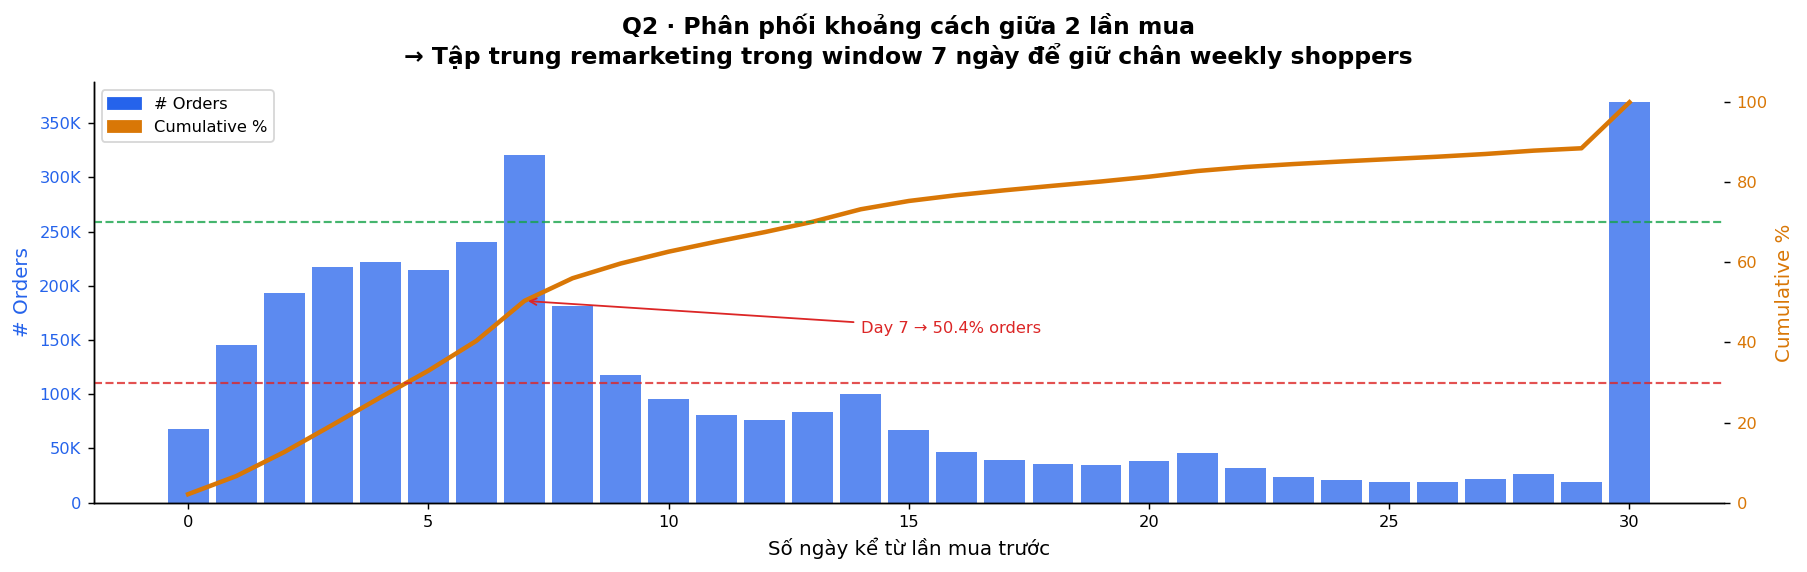

In [15]:
fig, ax1 = plt.subplots(figsize=(14, 4.5))

ax1.bar(q2_pd["gap_days"], q2_pd["n_orders"],
        color=C_BLUE, alpha=0.75, width=0.85, label="# Orders")
ax1.set_xlabel("Số ngày kể từ lần mua trước")
ax1.set_ylabel("# Orders", color=C_BLUE)
ax1.tick_params(axis="y", labelcolor=C_BLUE)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

ax2 = ax1.twinx()
ax2.plot(q2_pd["gap_days"], q2_pd["cum_pct"],
         color=C_AMBER, linewidth=2.5, label="Cumulative %")
ax2.axhline(30, color=C_RED, linestyle="--", linewidth=1.2, alpha=.8)
ax2.axhline(70, color=C_GREEN, linestyle="--", linewidth=1.2, alpha=.8)
ax2.set_ylabel("Cumulative %", color=C_AMBER)
ax2.tick_params(axis="y", labelcolor=C_AMBER)
ax2.set_ylim(0, 105)

# Mark 7-day threshold
idx7 = q2_pd[q2_pd["gap_days"] == 7].index[0]
cum7 = q2_pd.loc[idx7, "cum_pct"]
ax2.annotate(f"Day 7 → {cum7:.1f}% orders",
             xy=(7, cum7), xytext=(14, cum7 - 8),
             arrowprops=dict(arrowstyle="->", color=C_RED),
             fontsize=9, color=C_RED)

ax1.set_title("Q2 · Phân phối khoảng cách giữa 2 lần mua\n"
              "→ Tập trung remarketing trong window 7 ngày để giữ chân weekly shoppers",
              pad=10)
lines = [mpatches.Patch(color=C_BLUE, label="# Orders"),
         mpatches.Patch(color=C_AMBER, label="Cumulative %")]
ax1.legend(handles=lines, loc="upper left")
fig.tight_layout()
save_show(fig, "q2_gap_days_distribution")


---
## 📖 Chương 2 — Giỏ hàng trông như thế nào?
*Kích thước, thứ tự thêm vào giỏ, và xu hướng theo thời gian trung thành.*


### Q3 · Kích thước giỏ hàng (basket size) theo từng giờ
**Kỹ thuật:** `JOIN` + `COUNT DISTINCT` + `AVG` Aggregation

**Insight:** Giỏ hàng lớn nhất vào buổi tối (18–21h) — khách mua nhiều hơn khi về nhà sau giờ làm.


In [16]:
q3 = spark.sql("""
    SELECT
        CAST(o.order_hour_of_day AS INT)              AS hour,
        COUNT(DISTINCT o.order_id)                    AS n_orders,
        ROUND(COUNT(op.product_id) * 1.0
              / COUNT(DISTINCT o.order_id), 2)        AS avg_basket_size,
        ROUND(AVG(op.reordered) * 100, 2)             AS avg_reorder_pct
    FROM orders o
    JOIN order_products_all op ON o.order_id = op.order_id
    GROUP BY hour
    ORDER BY hour
""").cache()

q3_pd = q3.toPandas()
q3_pd.head()


,hour,n_orders,avg_basket_size,avg_reorder_pct
0,0,22224,10.26,56.57
1,1,12103,10.03,55.81
2,2,7375,9.85,55.56
3,3,5343,10.06,56.05
4,4,5393,10.33,57.24


TypeError: unsupported operand type(s) for *: 'decimal.Decimal' and 'float'

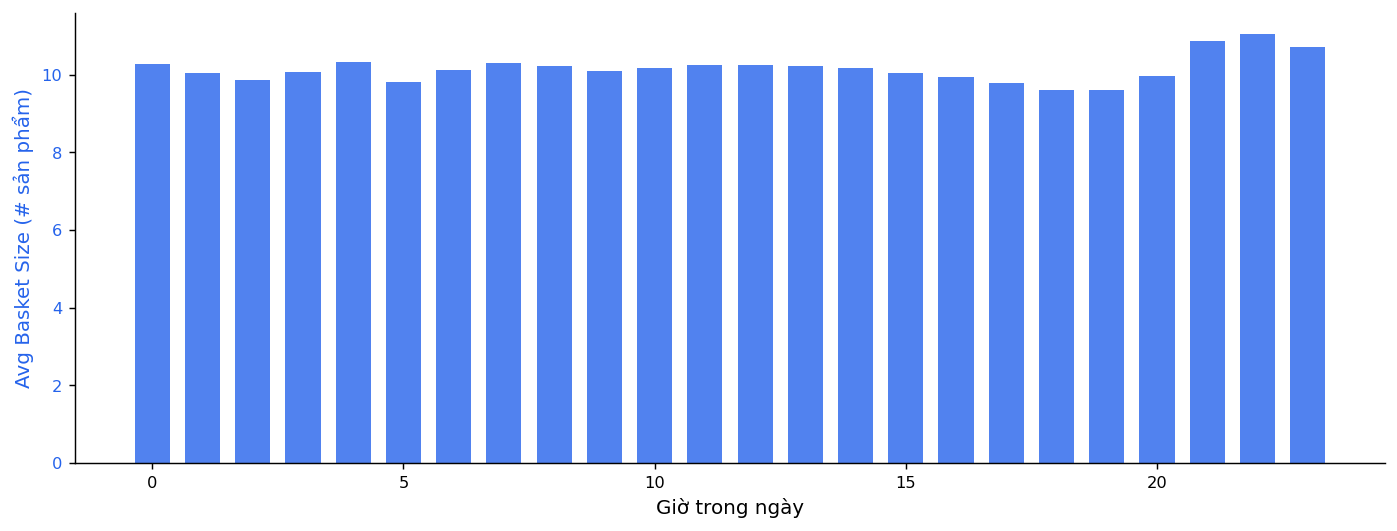

In [17]:
fig, ax1 = plt.subplots(figsize=(13, 4.5))

bars = ax1.bar(q3_pd["hour"], q3_pd["avg_basket_size"],
               color=C_BLUE, alpha=0.8, width=0.7, label="Avg Basket Size")
ax1.set_xlabel("Giờ trong ngày")
ax1.set_ylabel("Avg Basket Size (# sản phẩm)", color=C_BLUE)
ax1.tick_params(axis="y", labelcolor=C_BLUE)
ax1.set_ylim(0, q3_pd["avg_basket_size"].max() * 1.25)

ax2 = ax1.twinx()
ax2.plot(q3_pd["hour"], q3_pd["avg_reorder_pct"],
         color=C_AMBER, linewidth=2.5, marker="o", markersize=5,
         label="Avg Reorder %")
ax2.set_ylabel("Avg Reorder %", color=C_AMBER)
ax2.tick_params(axis="y", labelcolor=C_AMBER)

# Shade evening peak
ax1.axvspan(18, 21, alpha=0.08, color=C_PURPLE, label="Evening peak")

ax1.set_title("Q3 · Kích thước giỏ hàng & Reorder rate theo giờ\n"
              "→ Buổi tối giỏ lớn hơn nhưng reorder % không cao hơn → khách khám phá sản phẩm mới",
              pad=10)
lines = [mpatches.Patch(color=C_BLUE, label="Avg Basket"),
         mpatches.Patch(color=C_AMBER, label="Reorder %"),
         mpatches.Patch(color=C_PURPLE, alpha=0.2, label="18–21h")]
ax1.legend(handles=lines, loc="upper left")
fig.tight_layout()
save_show(fig, "q3_basket_size_by_hour")


### Q4 · Basket size & reorder rate thay đổi theo lần mua thứ N
**Kỹ thuật:** `JOIN` + `STDDEV()` + `GROUP BY order_number` (Time-Series theo loyalty)

**Insight:** Basket size ổn định sau lần thứ 5; reorder rate tăng đều — khách càng mua lâu càng "trung thành" với sản phẩm quen.


In [18]:
q4 = spark.sql("""
    WITH basket AS (
        SELECT o.order_number,
               o.order_id,
               COUNT(op.product_id) AS bsize,
               AVG(op.reordered)    AS rrate
        FROM orders o
        JOIN order_products_prior op ON o.order_id = op.order_id
        WHERE o.order_number <= 35
        GROUP BY o.order_number, o.order_id
    )
    SELECT
        order_number,
        COUNT(order_id)                AS n_orders,
        ROUND(AVG(bsize), 2)           AS avg_basket,
        ROUND(STDDEV(bsize), 2)        AS std_basket,
        ROUND(AVG(rrate) * 100, 2)     AS avg_reorder_pct
    FROM basket
    GROUP BY order_number
    ORDER BY order_number
""").cache()

q4_pd = q4.toPandas()
q4_pd.head(10)


,order_number,n_orders,avg_basket,std_basket,avg_reorder_pct
0,1,206209,10.08,7.47,0.00
1,2,206209,9.93,7.40,28.84
2,3,206209,9.94,7.47,40.51
3,4,182223,9.99,7.50,47.71
4,5,162633,10.01,7.49,52.59
5,6,146468,10.05,7.52,56.18
6,7,132618,10.06,7.53,59.16
7,8,120918,10.08,7.54,61.37
8,9,110728,10.12,7.55,63.40
9,10,101696,10.12,7.55,64.99


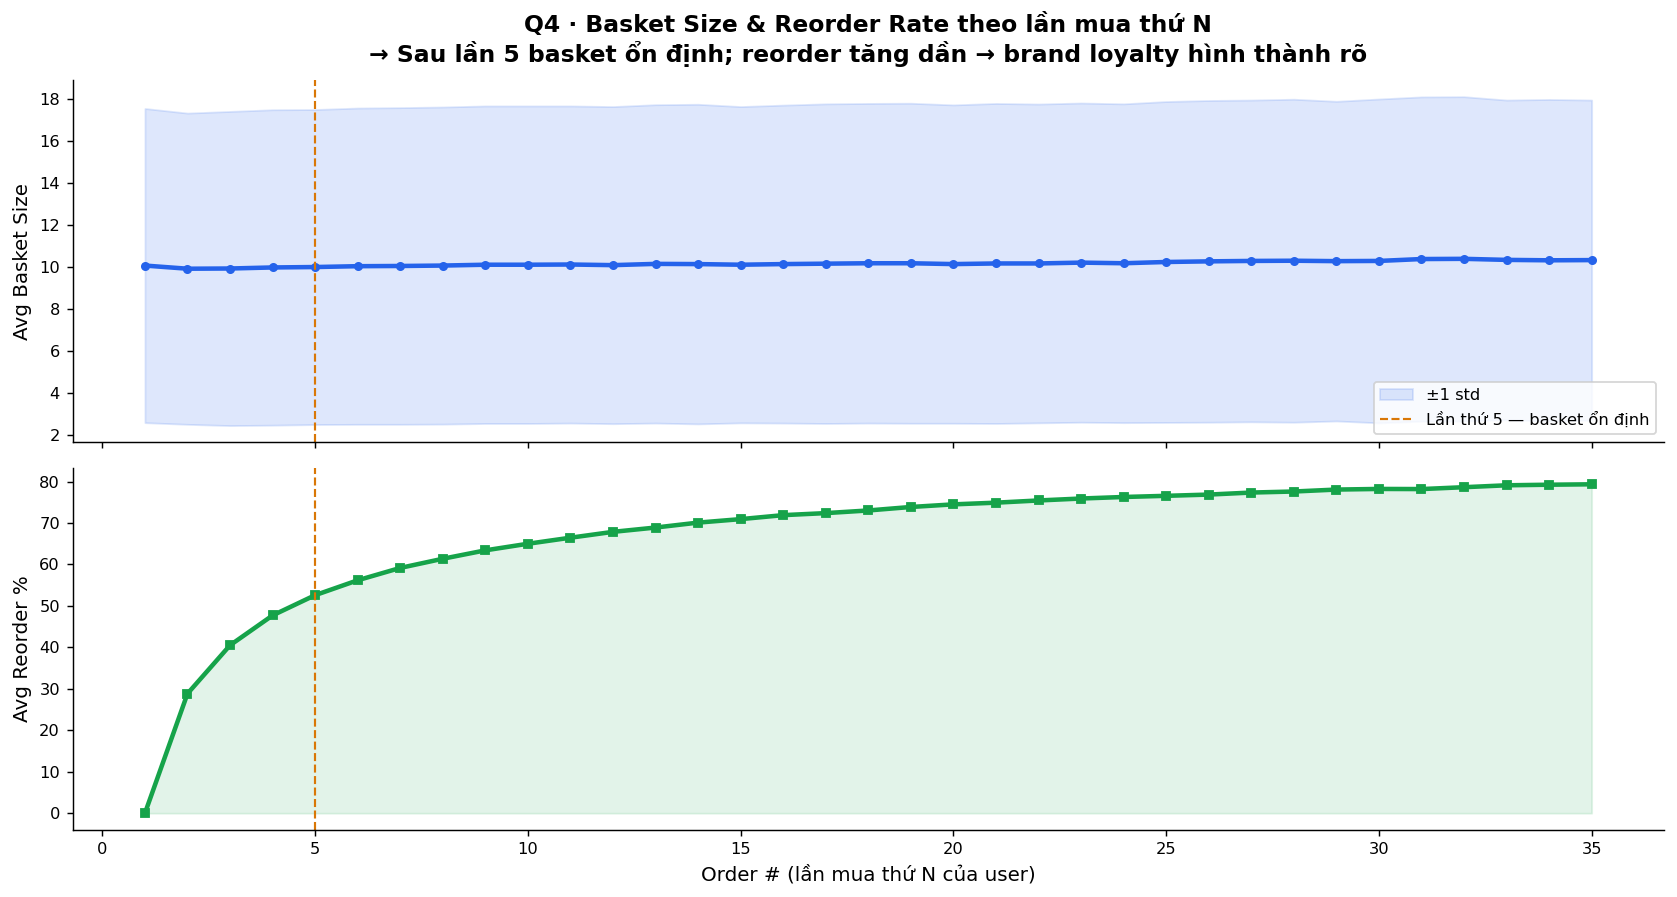

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Panel 1: basket size + confidence band
ax1.plot(q4_pd["order_number"], q4_pd["avg_basket"],
         color=C_BLUE, linewidth=2.5, marker="o", markersize=4)
ax1.fill_between(q4_pd["order_number"],
                 q4_pd["avg_basket"] - q4_pd["std_basket"],
                 q4_pd["avg_basket"] + q4_pd["std_basket"],
                 alpha=0.15, color=C_BLUE, label="±1 std")
ax1.axvline(5, color=C_AMBER, linestyle="--", linewidth=1.2,
            label="Lần thứ 5 — basket ổn định")
ax1.set_ylabel("Avg Basket Size")
ax1.legend(); ax1.set_title("Q4 · Basket Size & Reorder Rate theo lần mua thứ N\n"
    "→ Sau lần 5 basket ổn định; reorder tăng dần → brand loyalty hình thành rõ", pad=10)

# Panel 2: reorder %
ax2.plot(q4_pd["order_number"], q4_pd["avg_reorder_pct"],
         color=C_GREEN, linewidth=2.5, marker="s", markersize=4)
ax2.fill_between(q4_pd["order_number"], 0, q4_pd["avg_reorder_pct"],
                 alpha=0.12, color=C_GREEN)
ax2.set_xlabel("Order # (lần mua thứ N của user)")
ax2.set_ylabel("Avg Reorder %")
ax2.axvline(5, color=C_AMBER, linestyle="--", linewidth=1.2)

fig.tight_layout()
save_show(fig, "q4_basket_reorder_by_order_number")


---
## 📖 Chương 3 — Sản phẩm & Danh mục nào dẫn đầu?


### Q5 · Top 20 sản phẩm bán chạy nhất (màu = reorder rate)
**Kỹ thuật:** `JOIN` 4 bảng + `DENSE_RANK()` Window

**Insight:** Banana — sản phẩm #1 tuyệt đối. Nhóm fresh produce chiếm áp đảo top 20.


In [20]:
q5 = spark.sql("""
    SELECT
        p.product_name,
        d.department,
        COUNT(op.order_id)                                          AS total_sold,
        ROUND(SUM(op.reordered)*100.0 / COUNT(op.order_id), 1)     AS reorder_pct,
        DENSE_RANK() OVER (ORDER BY COUNT(op.order_id) DESC)        AS rnk
    FROM order_products_all op
    JOIN products    p ON op.product_id    = p.product_id
    JOIN departments d ON p.department_id  = d.department_id
    GROUP BY p.product_name, d.department
    ORDER BY total_sold DESC
    LIMIT 20
""").cache()

q5_pd = q5.toPandas()
q5_pd.head()


,product_name,department,total_sold,reorder_pct,rnk
0,Banana,produce,491291,84.5,1
1,Bag of Organic Bananas,produce,394930,83.4,2
2,Organic Strawberries,produce,275577,77.8,3
3,Organic Baby Spinach,produce,251705,77.4,4
4,Organic Hass Avocado,produce,220877,79.8,5


In [22]:
q5_s = q5_pd.sort_values("total_sold")
norm = plt.Normalize(q5_s["reorder_pct"].min(), q5_s["reorder_pct"].max())
cmap_r = LinearSegmentedColormap.from_list("rr", ["#BFDBFE","#1D4ED8"])
colors = cmap_r(norm(q5_s["reorder_pct"].values))

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(q5_s["product_name"], q5_s["total_sold"],
               color=colors, edgecolor="white", linewidth=0.4)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

for bar, rr in zip(bars, q5_s["reorder_pct"]):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            f"{rr:.0f}%", va="center", fontsize=8, color=C_GRAY)

sm = plt.cm.ScalarMappable(cmap=cmap_r, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label="Reorder Rate %", shrink=0.6, pad=0.01)

ax.set_xlabel("Tổng lượt mua")
ax.set_title("Q5 · Top 20 sản phẩm bán chạy — màu = reorder rate\n"
             "→ Fresh produce chiếm áp đảo; reorder rate cao → cần đảm bảo tồn kho liên tục",
             pad=10)
fig.tight_layout()
save_show(fig, "q5_top20_products")


TypeError: unsupported operand type(s) for -: 'decimal.Decimal' and 'float'

### Q6 · Reorder rate & doanh số theo Department — ma trận hiệu suất
**Kỹ thuật:** `JOIN` + `GROUP BY` + `RANK()` Window + hai chiều đánh giá

**Insight:** Tứ phân vị: *Star* (reorder cao, doanh số cao) vs *Opportunity* (reorder thấp, doanh số cao).


In [23]:
q6 = spark.sql("""
    SELECT
        d.department,
        COUNT(op.order_id)                                     AS total_sold,
        SUM(op.reordered)                                      AS total_reordered,
        ROUND(SUM(op.reordered)*100.0/COUNT(op.order_id), 2)   AS reorder_pct,
        RANK() OVER (ORDER BY COUNT(op.order_id) DESC)         AS sales_rank,
        RANK() OVER (ORDER BY SUM(op.reordered)*1.0/COUNT(op.order_id) DESC) AS reorder_rank
    FROM order_products_all op
    JOIN products    p ON op.product_id    = p.product_id
    JOIN departments d ON p.department_id  = d.department_id
    GROUP BY d.department
    ORDER BY reorder_pct DESC
""").cache()

q6_pd = q6.toPandas()
q6_pd.head()


,department,total_sold,total_reordered,reorder_pct,sales_rank,reorder_rank
0,dairy eggs,5631067,3773723,67.02,2,1
1,beverages,2804175,1832952,65.37,4,2
2,produce,9888378,6432596,65.05,1,3
3,bakery,1225181,769880,62.84,7,4
4,deli,1095540,666231,60.81,9,5


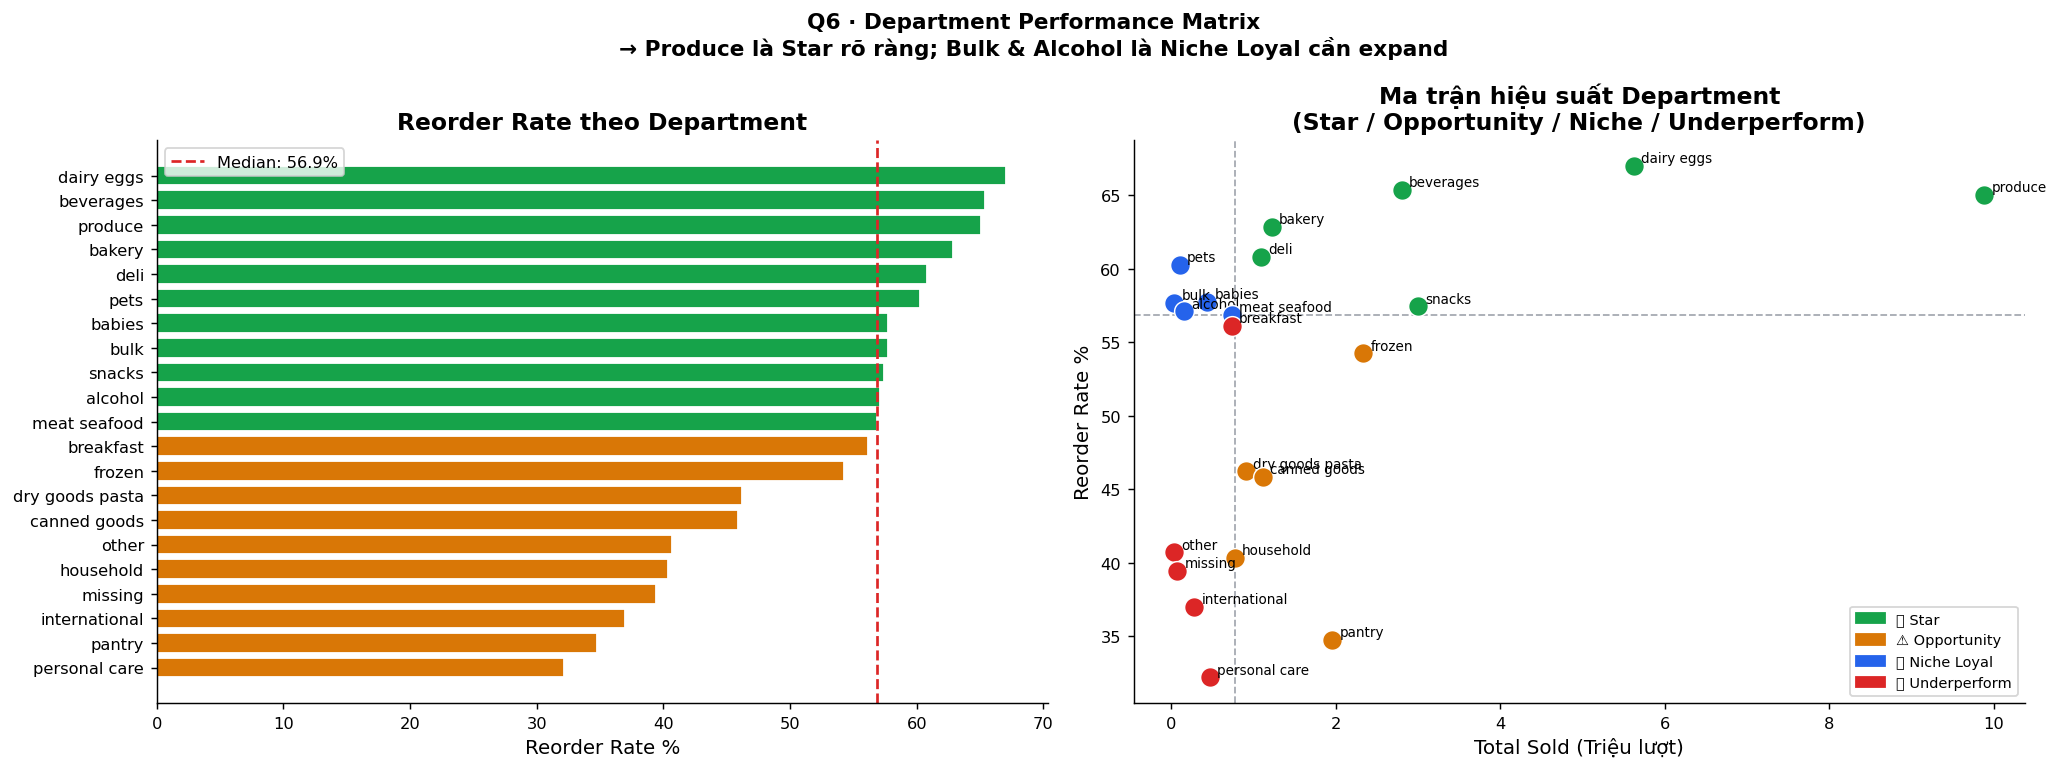

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Horizontal bar — reorder %
q6_s = q6_pd.sort_values("reorder_pct")
bar_colors = [C_GREEN if v >= q6_pd["reorder_pct"].median() else C_AMBER
              for v in q6_s["reorder_pct"]]
ax1.barh(q6_s["department"], q6_s["reorder_pct"],
         color=bar_colors, edgecolor="white")
ax1.axvline(q6_pd["reorder_pct"].median(), color=C_RED, linestyle="--",
            linewidth=1.5, label=f'Median: {q6_pd["reorder_pct"].median():.1f}%')
ax1.set_xlabel("Reorder Rate %")
ax1.set_title("Reorder Rate theo Department")
ax1.legend()

# RIGHT: Scatter — sales vs reorder (performance matrix)
med_sold = q6_pd["total_sold"].median()
med_rr   = q6_pd["reorder_pct"].median()

for _, row in q6_pd.iterrows():
    if row["total_sold"] >= med_sold and row["reorder_pct"] >= med_rr:
        c = C_GREEN; label = "⭐ Star"
    elif row["total_sold"] >= med_sold:
        c = C_AMBER; label = "⚠️ Opportunity"
    elif row["reorder_pct"] >= med_rr:
        c = C_BLUE; label = "🔵 Niche Loyal"
    else:
        c = C_RED; label = "❌ Underperform"
    ax2.scatter(row["total_sold"]/1e6, row["reorder_pct"],
                s=120, color=c, zorder=3, edgecolors="white", linewidth=0.8)
    ax2.annotate(row["department"],
                 (row["total_sold"]/1e6, row["reorder_pct"]),
                 fontsize=7.5, xytext=(4, 2), textcoords="offset points")

ax2.axvline(med_sold/1e6, color=C_GRAY, linestyle="--", linewidth=1, alpha=.6)
ax2.axhline(med_rr, color=C_GRAY, linestyle="--", linewidth=1, alpha=.6)
ax2.set_xlabel("Total Sold (Triệu lượt)")
ax2.set_ylabel("Reorder Rate %")
ax2.set_title("Ma trận hiệu suất Department\n(Star / Opportunity / Niche / Underperform)")

legend_els = [mpatches.Patch(color=C_GREEN, label="⭐ Star"),
              mpatches.Patch(color=C_AMBER, label="⚠️ Opportunity"),
              mpatches.Patch(color=C_BLUE,  label="🔵 Niche Loyal"),
              mpatches.Patch(color=C_RED,   label="❌ Underperform")]
ax2.legend(handles=legend_els, fontsize=8, loc="lower right")

fig.suptitle("Q6 · Department Performance Matrix\n"
             "→ Produce là Star rõ ràng; Bulk & Alcohol là Niche Loyal cần expand",
             fontsize=12, fontweight="bold")
fig.tight_layout()
save_show(fig, "q6_department_matrix")


### Q7 · Top 15 Aisle — doanh số và số SKU
**Kỹ thuật:** `JOIN` 4 bảng + `COUNT DISTINCT` + `RANK()` Window

**Insight:** Fresh Fruits & Vegetables top 2; nhưng Fresh Herbs có rất ít SKU mà vẫn lọt top → efficiency cao.


In [25]:
q7 = spark.sql("""
    SELECT
        a.aisle,
        d.department,
        COUNT(op.order_id)              AS total_sold,
        COUNT(DISTINCT p.product_id)    AS unique_skus,
        ROUND(AVG(op.reordered)*100, 2) AS reorder_pct,
        RANK() OVER (ORDER BY COUNT(op.order_id) DESC) AS rnk
    FROM order_products_all op
    JOIN products    p ON op.product_id    = p.product_id
    JOIN aisles      a ON p.aisle_id       = a.aisle_id
    JOIN departments d ON p.department_id  = d.department_id
    GROUP BY a.aisle, d.department
    ORDER BY total_sold DESC
    LIMIT 15
""").cache()

q7_pd = q7.toPandas()
q7_pd["sold_per_sku"] = (q7_pd["total_sold"] / q7_pd["unique_skus"]).round(0)
q7_pd.head()


,aisle,department,total_sold,unique_skus,reorder_pct,rnk,sold_per_sku
0,fresh fruits,produce,3792661,382,71.88,1,9928.0
1,fresh vegetables,produce,3568630,569,59.51,2,6272.0
2,packaged vegetables fruits,produce,1843806,615,63.93,3,2998.0
3,yogurt,dairy eggs,1507583,1026,68.65,4,1469.0
4,packaged cheese,dairy eggs,1021462,891,58.57,5,1146.0


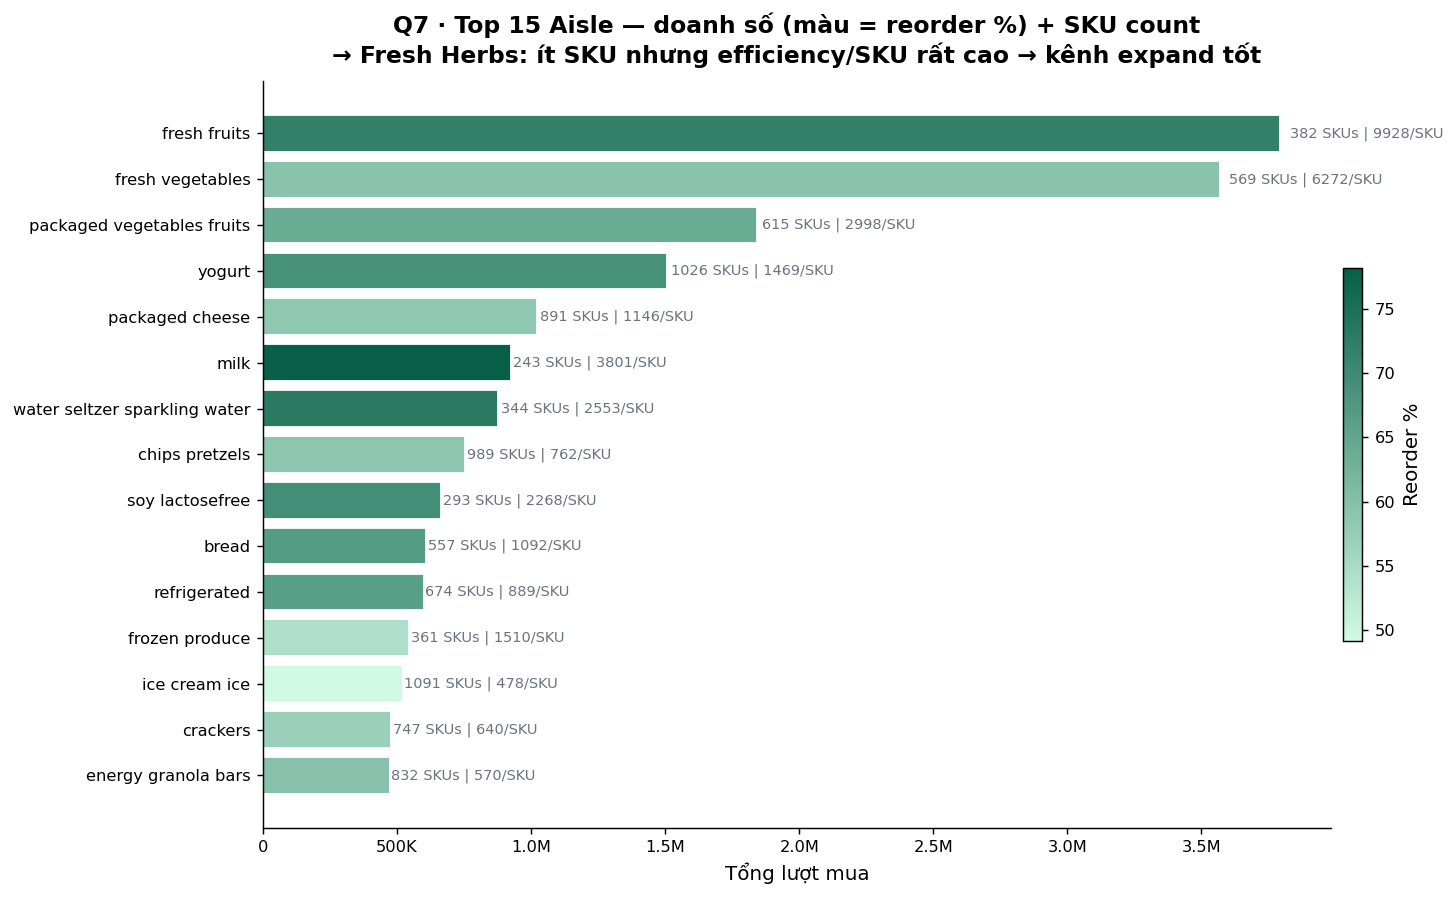

In [28]:
q7_s = q7_pd.sort_values("total_sold")
fig, ax = plt.subplots(figsize=(12, 7))

norm_rr = plt.Normalize(q7_s["reorder_pct"].min(), q7_s["reorder_pct"].max())
cmap_g  = LinearSegmentedColormap.from_list("gg", ["#D1FAE5","#065F46"])
colors  = cmap_g(norm_rr(q7_s["reorder_pct"].values))

bars = ax.barh(q7_s["aisle"], q7_s["total_sold"],
               color=colors, edgecolor="white")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

# SKU annotation
for bar, sku, spsku in zip(bars, q7_s["unique_skus"], q7_s["sold_per_sku"]):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            f"{int(sku)} SKUs | {int(spsku)}/SKU",
            va="center", fontsize=8, color=C_GRAY)

sm = plt.cm.ScalarMappable(cmap=cmap_g, norm=norm_rr)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Reorder %", shrink=0.5, pad=0.01)

ax.set_xlabel("Tổng lượt mua")
ax.set_title("Q7 · Top 15 Aisle — doanh số (màu = reorder %) + SKU count\n"
             "→ Fresh Herbs: ít SKU nhưng efficiency/SKU rất cao → kênh expand tốt",
             pad=10)
fig.tight_layout()
save_show(fig, "q7_top15_aisles")


### Q8 · Organic vs Non-Organic — hành vi mua hàng khác nhau thế nào?
**Kỹ thuật:** `LOWER() + LIKE` string matching + `JOIN` + `GROUP BY`

**Insight:** Organic chiếm ~12% volume nhưng reorder rate cao hơn → nhóm khách hàng trung thành, premium.


In [29]:
q8 = spark.sql("""
    SELECT
        CASE WHEN LOWER(p.product_name) LIKE '%organic%'
             THEN 'Organic' ELSE 'Non-Organic' END       AS product_type,
        COUNT(op.order_id)                               AS total_sold,
        COUNT(DISTINCT p.product_id)                     AS unique_products,
        ROUND(AVG(op.reordered)*100, 2)                  AS avg_reorder_pct,
        ROUND(AVG(op.add_to_cart_order), 2)              AS avg_cart_position
    FROM order_products_all op
    JOIN products p ON op.product_id = p.product_id
    GROUP BY product_type
    ORDER BY total_sold DESC
""").cache()

q8_pd = q8.toPandas()
q8_pd


,product_type,total_sold,unique_products,avg_reorder_pct,avg_cart_position
0,Non-Organic,23162774,44649,56.92,8.35
1,Organic,10656332,5036,63.54,8.41


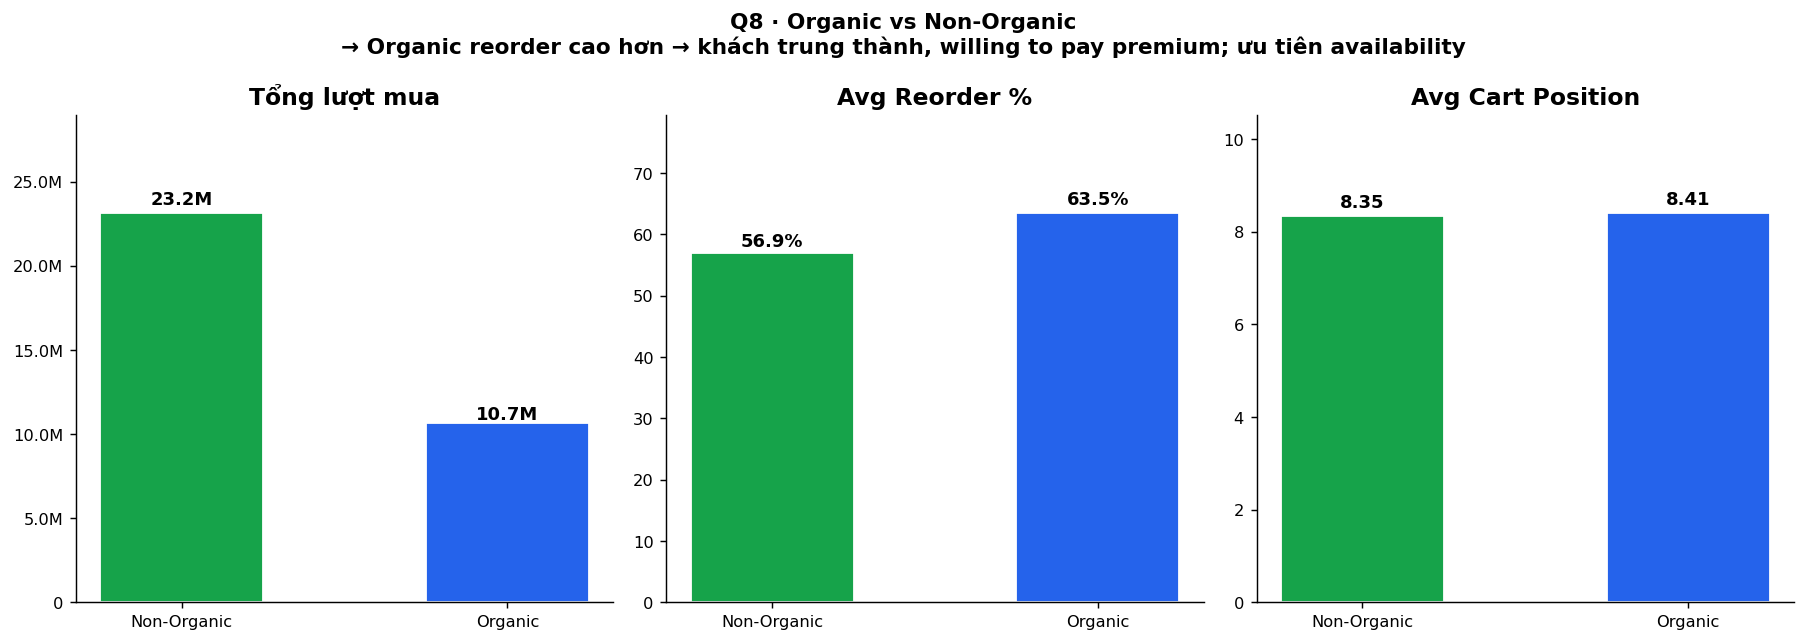

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = [("total_sold",        "Tổng lượt mua",       fmt_k),
           ("avg_reorder_pct",   "Avg Reorder %",        lambda x,_: f"{x:.1f}%"),
           ("avg_cart_position", "Avg Cart Position",    lambda x,_: f"{x:.2f}")]
colors_org = [C_GREEN, C_BLUE]

for ax, (col, label, fmter) in zip(axes, metrics):
    bars = ax.bar(q8_pd["product_type"], q8_pd[col],
                  color=colors_org, width=0.5, edgecolor="white")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                fmter(bar.get_height(), None),
                ha="center", fontsize=10, fontweight="bold")
    ax.set_title(label)
    ax.set_ylim(0, q8_pd[col].max() * 1.25)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        fmt_k if col=="total_sold" else lambda x,_: f"{x:.0f}"))

fig.suptitle("Q8 · Organic vs Non-Organic\n"
             "→ Organic reorder cao hơn → khách trung thành, willing to pay premium; ưu tiên availability",
             fontsize=12, fontweight="bold")
fig.tight_layout()
save_show(fig, "q8_organic_vs_nonorganic")


---
## 📖 Chương 4 — Điều gì khiến khách quay lại?
*Phân tích reorder behavior sâu hơn.*


### Q9 · Reorder rate theo vị trí thêm vào giỏ hàng (cart funnel)
**Kỹ thuật:** `CASE WHEN` bucketing + `GROUP BY` + `AVG Aggregation`

**Insight:** Sản phẩm được thêm đầu tiên có reorder rate cao nhất → chúng là "staples" của khách hàng.


In [31]:
q9 = spark.sql("""
    SELECT
        CASE
            WHEN add_to_cart_order = 1    THEN '1) First item'
            WHEN add_to_cart_order <= 3   THEN '2) 2-3 Early'
            WHEN add_to_cart_order <= 7   THEN '3) 4-7 Mid-early'
            WHEN add_to_cart_order <= 15  THEN '4) 8-15 Middle'
            ELSE                               '5) 16+ Late'
        END                              AS cart_bucket,
        COUNT(*)                         AS total_items,
        ROUND(AVG(reordered)*100, 2)     AS avg_reorder_pct,
        ROUND(AVG(add_to_cart_order), 1) AS avg_position
    FROM order_products_all
    GROUP BY cart_bucket
    ORDER BY avg_position
""").cache()

q9_pd = q9.toPandas()
q9_pd


,cart_bucket,total_items,avg_reorder_pct,avg_position
0,1) First item,3346083,67.93,1.0
1,2) 2-3 Early,6170619,66.81,2.5
2,3) 4-7 Mid-early,9690546,61.24,5.4
3,4) 8-15 Middle,9859148,54.51,10.8
4,5) 16+ Late,4752710,47.36,22.2


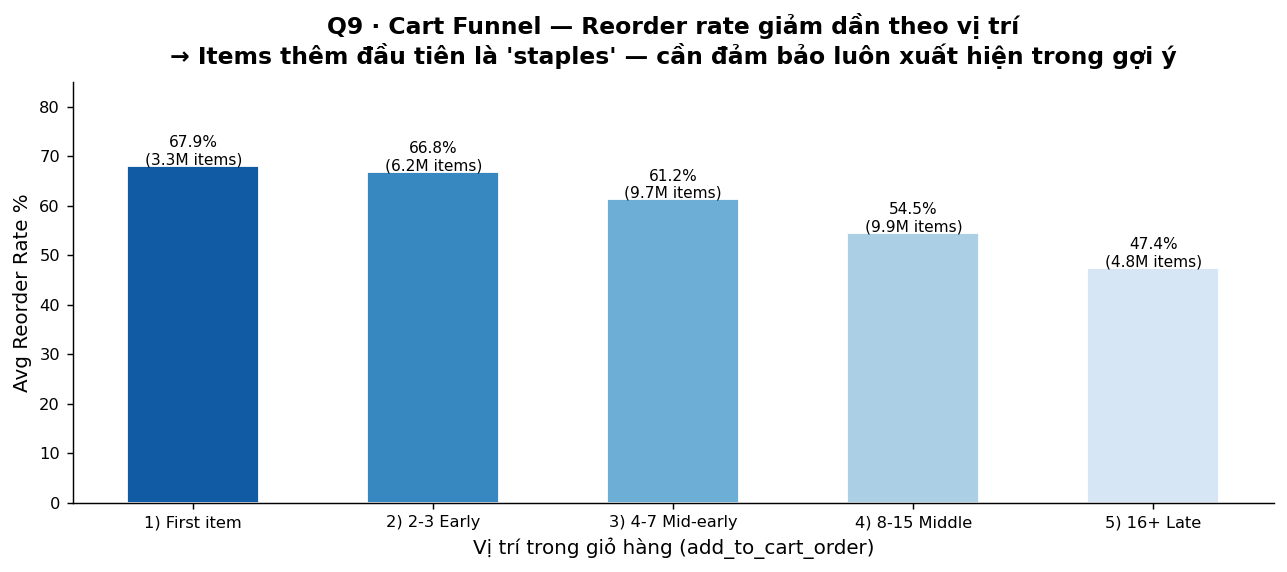

In [32]:
fig, ax = plt.subplots(figsize=(10, 4.5))

bar_colors = sns.color_palette("Blues_r", len(q9_pd))
bars = ax.bar(q9_pd["cart_bucket"], q9_pd["avg_reorder_pct"],
              color=bar_colors, edgecolor="white", width=0.55)

for bar, total in zip(bars, q9_pd["total_items"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%\n({fmt_k(total, None)} items)",
            ha="center", fontsize=8.5)

ax.set_ylabel("Avg Reorder Rate %")
ax.set_xlabel("Vị trí trong giỏ hàng (add_to_cart_order)")
ax.set_ylim(0, q9_pd["avg_reorder_pct"].max() * 1.25)
ax.set_title("Q9 · Cart Funnel — Reorder rate giảm dần theo vị trí\n"
             "→ Items thêm đầu tiên là 'staples' — cần đảm bảo luôn xuất hiện trong gợi ý",
             pad=10)
fig.tight_layout()
save_show(fig, "q9_cart_funnel_reorder")


### Q10 · First-buy vs Reorder — stacked breakdown theo Department
**Kỹ thuật:** `SUM(CASE WHEN)` + `JOIN` + `GROUP BY` — phân tách acquisition vs retention

**Insight:** Bulk & Personal Care có first-buy % cao → đây là danh mục "thử lần đầu" — cần chuyển đổi thành reorder.


In [33]:
q10 = spark.sql("""
    SELECT
        d.department,
        COUNT(*)                                                      AS total,
        SUM(CASE WHEN op.reordered = 0 THEN 1 ELSE 0 END)            AS first_buy,
        SUM(CASE WHEN op.reordered = 1 THEN 1 ELSE 0 END)            AS reorder,
        ROUND(SUM(CASE WHEN op.reordered=0 THEN 1 ELSE 0 END)*100.0
              / COUNT(*), 1)                                          AS first_buy_pct,
        ROUND(SUM(CASE WHEN op.reordered=1 THEN 1 ELSE 0 END)*100.0
              / COUNT(*), 1)                                          AS reorder_pct
    FROM order_products_all op
    JOIN products    p ON op.product_id    = p.product_id
    JOIN departments d ON p.department_id  = d.department_id
    GROUP BY d.department
    ORDER BY reorder_pct DESC
""").cache()

q10_pd = q10.toPandas()
q10_pd.head()


,department,total,first_buy,reorder,first_buy_pct,reorder_pct
0,dairy eggs,5631067,1857344,3773723,33.0,67.0
1,beverages,2804175,971223,1832952,34.6,65.4
2,produce,9888378,3455782,6432596,34.9,65.1
3,bakery,1225181,455301,769880,37.2,62.8
4,deli,1095540,429309,666231,39.2,60.8


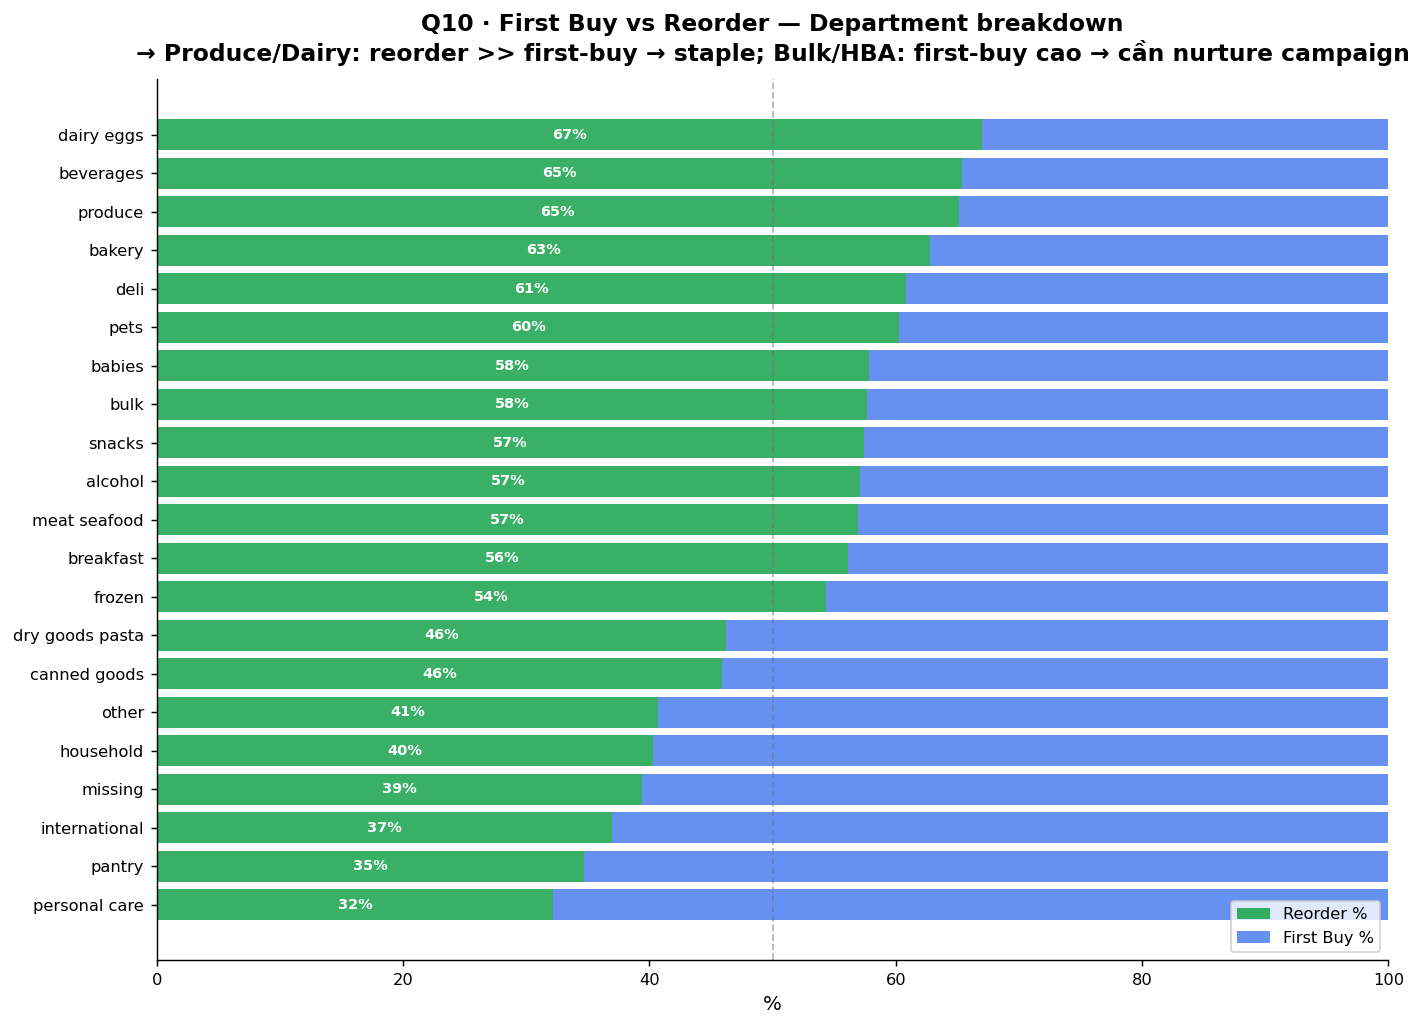

In [34]:
q10_s = q10_pd.sort_values("reorder_pct")
fig, ax = plt.subplots(figsize=(11, 8))

ax.barh(q10_s["department"], q10_s["reorder_pct"],
        color=C_GREEN, alpha=0.85, label="Reorder %")
ax.barh(q10_s["department"], q10_s["first_buy_pct"],
        left=q10_s["reorder_pct"],
        color=C_BLUE, alpha=0.7, label="First Buy %")

# Annotations: reorder % value
for _, row in q10_s.iterrows():
    ax.text(row["reorder_pct"]/2, row["department"],
            f"{row['reorder_pct']:.0f}%", va="center", ha="center",
            fontsize=8, color="white", fontweight="bold")

ax.set_xlabel("%")
ax.set_xlim(0, 100)
ax.axvline(50, color=C_GRAY, linestyle="--", linewidth=1, alpha=.5)
ax.legend(loc="lower right")
ax.set_title("Q10 · First Buy vs Reorder — Department breakdown\n"
             "→ Produce/Dairy: reorder >> first-buy → staple; "
             "Bulk/HBA: first-buy cao → cần nurture campaign",
             pad=10)
fig.tight_layout()
save_show(fig, "q10_firstbuy_vs_reorder_dept")


### Q11 · Top 15 sản phẩm: Reorder rate cao nhất (có đủ volume)
**Kỹ thuật:** `JOIN` 4 bảng + `HAVING COUNT > threshold` + `ORDER BY` reorder DESC

**Insight:** Nước khoáng, sữa hữu cơ, quả mọng — reorder gần như tuyệt đối → must-stock items.


In [35]:
q11 = spark.sql("""
    SELECT
        p.product_name,
        a.aisle,
        d.department,
        COUNT(op.order_id)              AS total_sold,
        ROUND(AVG(op.reordered)*100, 1) AS reorder_pct
    FROM order_products_all op
    JOIN products    p ON op.product_id    = p.product_id
    JOIN aisles      a ON p.aisle_id       = a.aisle_id
    JOIN departments d ON p.department_id  = d.department_id
    GROUP BY p.product_name, a.aisle, d.department
    HAVING COUNT(op.order_id) >= 3000
    ORDER BY reorder_pct DESC
    LIMIT 15
""").cache()

q11_pd = q11.toPandas()
q11_pd.head()


,product_name,aisle,department,total_sold,reorder_pct
0,Whole Organic Omega 3 Milk,milk,dairy eggs,9410,86.0
1,Organic Lactose Free Whole Milk,soy lactosefree,dairy eggs,8742,85.9
2,Organic Homogenized Whole Milk,milk,dairy eggs,4095,85.8
3,"Milk, Organic, Vitamin D",milk,dairy eggs,20770,85.5
4,Organic Reduced Fat Milk,milk,dairy eggs,36869,85.2


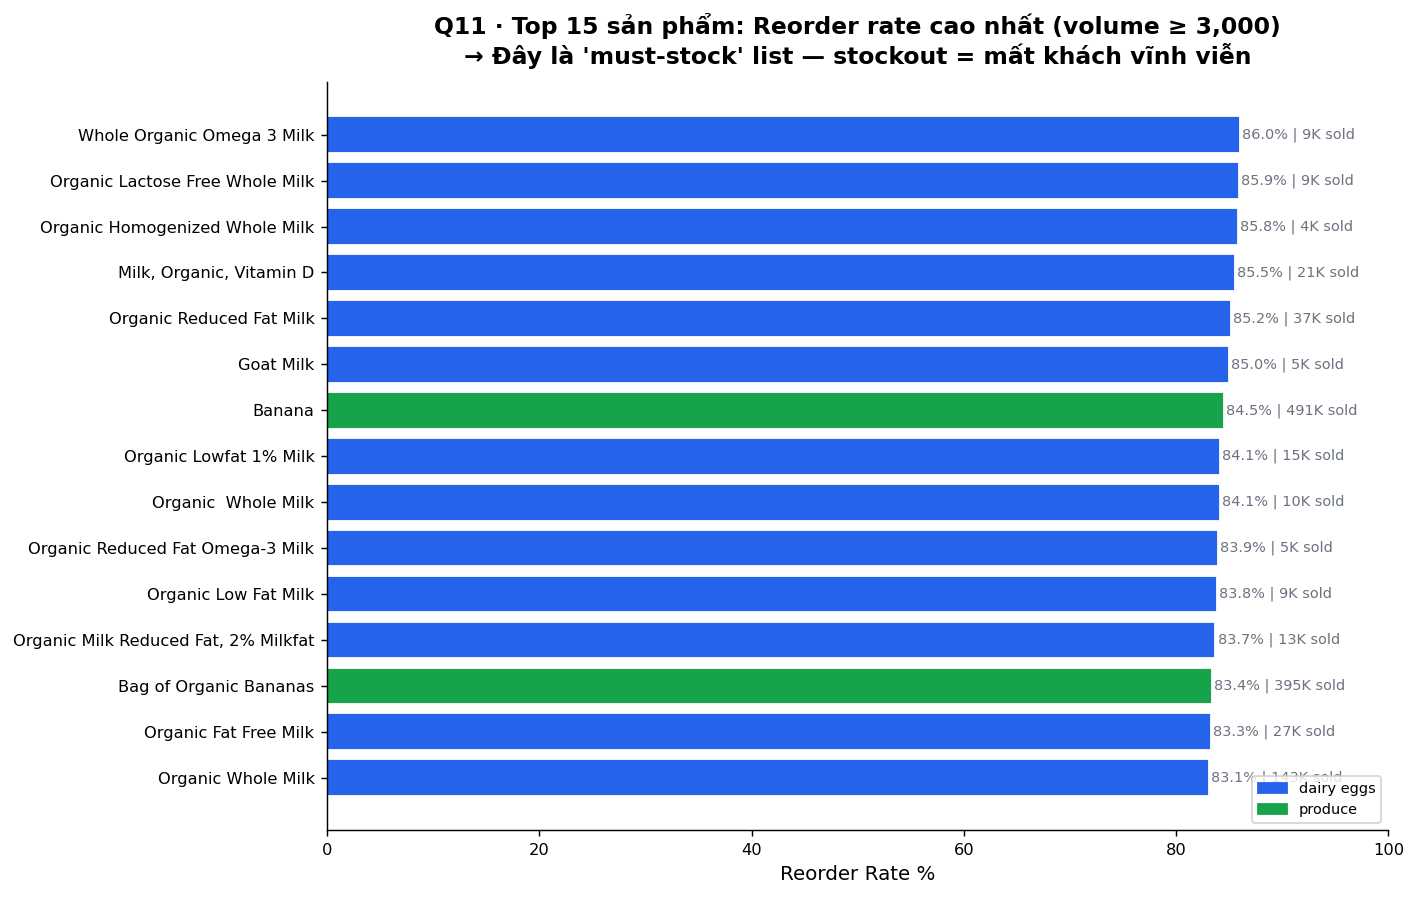

In [36]:
q11_s = q11_pd.sort_values("reorder_pct")
fig, ax = plt.subplots(figsize=(11, 7))

dept_colors = {d: PALETTE[i % len(PALETTE)]
               for i, d in enumerate(q11_s["department"].unique())}
bar_colors  = [dept_colors[d] for d in q11_s["department"]]

bars = ax.barh(q11_s["product_name"], q11_s["reorder_pct"],
               color=bar_colors, edgecolor="white")
for bar, sold in zip(bars, q11_s["total_sold"]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}% | {fmt_k(sold, None)} sold",
            va="center", fontsize=8, color=C_GRAY)

ax.set_xlim(0, 100)
ax.set_xlabel("Reorder Rate %")
ax.set_title("Q11 · Top 15 sản phẩm: Reorder rate cao nhất (volume ≥ 3,000)\n"
             "→ Đây là 'must-stock' list — stockout = mất khách vĩnh viễn",
             pad=10)

legend_h = [mpatches.Patch(color=c, label=d)
            for d, c in dept_colors.items()]
ax.legend(handles=legend_h, fontsize=8, loc="lower right")
fig.tight_layout()
save_show(fig, "q11_top15_highest_reorder")


---
## 📖 Chương 5 — Cơ hội kinh doanh
*Co-occurrence, hidden gems và portfolio efficiency.*


### Q12 · Top cặp sản phẩm hay được mua cùng nhau (Market Basket / Co-occurrence)
**Kỹ thuật:** `Self-JOIN` + `CTE` + `IN Subquery` (popular filter) + `GROUP BY pair`

**Insight:** Banana + Bag of Organic Bananas — cặp đôi #1. Có thể bundle hoặc cross-promote.


In [37]:
q12 = spark.sql("""
    WITH popular AS (
        SELECT product_id
        FROM order_products_prior
        GROUP BY product_id
        HAVING COUNT(*) > 50000
    ),
    pairs AS (
        SELECT a.product_id AS pa, b.product_id AS pb
        FROM order_products_prior a
        JOIN order_products_prior b
             ON a.order_id = b.order_id AND a.product_id < b.product_id
        WHERE a.product_id IN (SELECT product_id FROM popular)
          AND b.product_id IN (SELECT product_id FROM popular)
    )
    SELECT
        p1.product_name AS product_a,
        p2.product_name AS product_b,
        COUNT(*)         AS co_occurrence
    FROM pairs
    JOIN products p1 ON pairs.pa = p1.product_id
    JOIN products p2 ON pairs.pb = p2.product_id
    GROUP BY p1.product_name, p2.product_name
    ORDER BY co_occurrence DESC
    LIMIT 20
""").cache()

q12_pd = q12.toPandas()
q12_pd.head()


,product_a,product_b,co_occurrence
0,Bag of Organic Bananas,Organic Hass Avocado,62341
1,Bag of Organic Bananas,Organic Strawberries,61628
2,Organic Strawberries,Banana,56156
3,Banana,Organic Avocado,53395
4,Organic Baby Spinach,Banana,51395


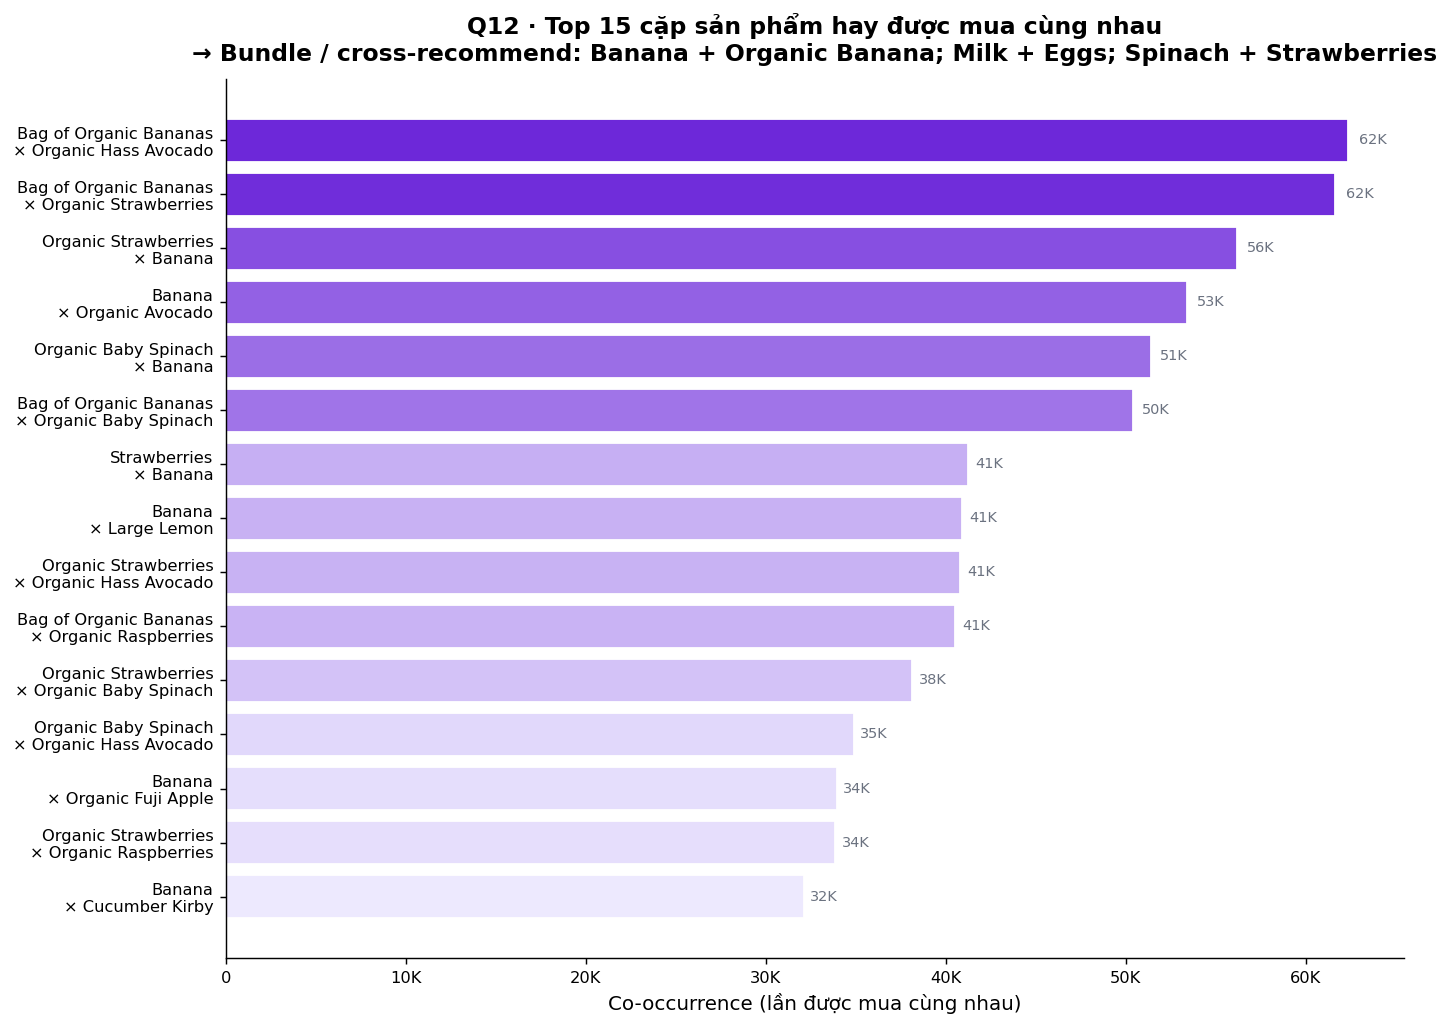

In [38]:
q12_pd["pair"] = (q12_pd["product_a"].str[:26]
                  + "\n× " + q12_pd["product_b"].str[:26])
q12_s = q12_pd.sort_values("co_occurrence").tail(15)

norm_c = plt.Normalize(q12_s["co_occurrence"].min(), q12_s["co_occurrence"].max())
cmap_p = LinearSegmentedColormap.from_list("pp", ["#EDE9FE","#6D28D9"])
colors = cmap_p(norm_c(q12_s["co_occurrence"].values))

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(q12_s["pair"], q12_s["co_occurrence"],
               color=colors, edgecolor="white")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
for bar in bars:
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            fmt_k(bar.get_width(), None),
            va="center", fontsize=8, color=C_GRAY)

ax.set_xlabel("Co-occurrence (lần được mua cùng nhau)")
ax.set_title("Q12 · Top 15 cặp sản phẩm hay được mua cùng nhau\n"
             "→ Bundle / cross-recommend: Banana + Organic Banana; Milk + Eggs; Spinach + Strawberries",
             pad=10)
fig.tight_layout()
save_show(fig, "q12_product_cooccurrence")


### Q13 · Department nào bán tốt nhất theo khung giờ? (Cross-dimension heatmap)
**Kỹ thuật:** `CTE` + `CASE WHEN` time bucket + `PARTITION BY` Window `RANK()`

**Insight:** Produce thống trị mọi khung giờ; Deli/Beverages nổi bật vào buổi tối — cơ hội evening promotion.


In [39]:
q13 = spark.sql("""
    WITH dept_slot AS (
        SELECT
            CASE
                WHEN CAST(o.order_hour_of_day AS INT) BETWEEN 6  AND 11 THEN 'A. 06-11 Sáng'
                WHEN CAST(o.order_hour_of_day AS INT) BETWEEN 12 AND 17 THEN 'B. 12-17 Chiều'
                WHEN CAST(o.order_hour_of_day AS INT) BETWEEN 18 AND 21 THEN 'C. 18-21 Tối'
                ELSE                                                          'D. 22-05 Đêm'
            END                 AS time_slot,
            d.department,
            COUNT(*)            AS items_sold
        FROM orders o
        JOIN order_products_all op ON o.order_id      = op.order_id
        JOIN products           p  ON op.product_id   = p.product_id
        JOIN departments        d  ON p.department_id = d.department_id
        GROUP BY time_slot, d.department
    ),
    ranked AS (
        SELECT *,
            RANK() OVER (PARTITION BY time_slot ORDER BY items_sold DESC) AS rnk
        FROM dept_slot
    )
    SELECT time_slot, department, items_sold, rnk
    FROM ranked
    WHERE rnk <= 7
    ORDER BY time_slot, rnk
""").cache()

q13_pd = q13.toPandas()
q13_pd.head(12)


,time_slot,department,items_sold,rnk
0,A. 06-11 Sáng,produce,3305825,1
1,A. 06-11 Sáng,dairy eggs,1941826,2
2,A. 06-11 Sáng,snacks,1035165,3
3,A. 06-11 Sáng,beverages,967649,4
4,A. 06-11 Sáng,frozen,704040,5
5,A. 06-11 Sáng,pantry,637467,6
6,A. 06-11 Sáng,bakery,410633,7
7,B. 12-17 Chiều,produce,4638072,1
8,B. 12-17 Chiều,dairy eggs,2603925,2
9,B. 12-17 Chiều,snacks,1416890,3


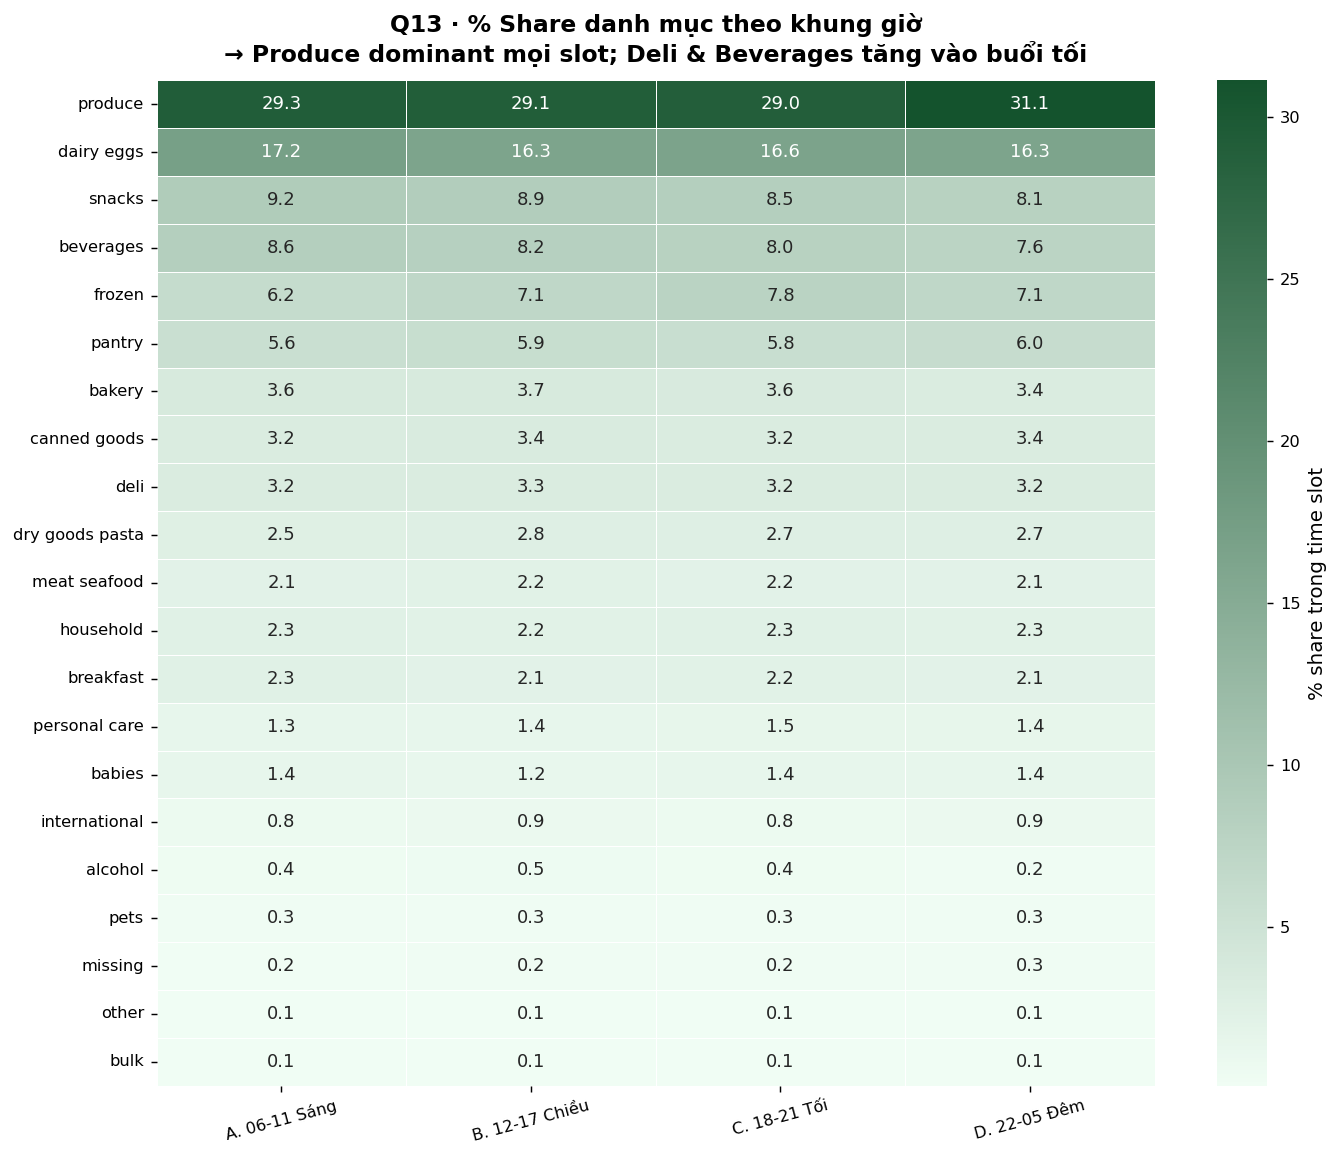

In [40]:
# Build full pivot for heatmap (all depts × all slots)
q13_full = spark.sql("""
    SELECT
        CASE
            WHEN CAST(o.order_hour_of_day AS INT) BETWEEN 6  AND 11 THEN 'A. 06-11 Sáng'
            WHEN CAST(o.order_hour_of_day AS INT) BETWEEN 12 AND 17 THEN 'B. 12-17 Chiều'
            WHEN CAST(o.order_hour_of_day AS INT) BETWEEN 18 AND 21 THEN 'C. 18-21 Tối'
            ELSE                                                          'D. 22-05 Đêm'
        END AS time_slot,
        d.department,
        COUNT(*) AS items_sold
    FROM orders o
    JOIN order_products_all op ON o.order_id = op.order_id
    JOIN products           p  ON op.product_id = p.product_id
    JOIN departments        d  ON p.department_id = d.department_id
    GROUP BY time_slot, d.department
""").toPandas()

pivot13 = q13_full.pivot(index="department", columns="time_slot", values="items_sold").fillna(0)
pivot13_norm = pivot13.div(pivot13.sum(axis=0), axis=1) * 100  # % share within slot

fig, ax = plt.subplots(figsize=(11, 9))
cmap_h = LinearSegmentedColormap.from_list("bw", ["#F0FDF4","#14532D"])
sns.heatmap(pivot13_norm.sort_values("B. 12-17 Chiều", ascending=False),
            ax=ax, cmap=cmap_h, annot=True, fmt=".1f",
            linewidths=0.4, cbar_kws={"label": "% share trong time slot"})
ax.set_title("Q13 · % Share danh mục theo khung giờ\n"
             "→ Produce dominant mọi slot; Deli & Beverages tăng vào buổi tối",
             pad=10)
ax.set_xlabel(""); ax.set_ylabel("")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
save_show(fig, "q13_dept_timeslot_heatmap")


### Q14 · Hidden Gems — sản phẩm reorder cao nhưng volume thấp (Subquery)
**Kỹ thuật:** `Inline Subquery (Derived Table)` + `JOIN` 4 bảng + `HAVING` + `WHERE` range

**Insight:** Các sản phẩm này đã có loyal fanbase nhỏ — tăng visibility có thể tạo growth đáng kể.


In [41]:
q14 = spark.sql("""
    SELECT *
    FROM (
        SELECT
            p.product_name,
            a.aisle,
            d.department,
            COUNT(op.order_id)              AS total_orders,
            ROUND(AVG(op.reordered)*100, 1) AS reorder_pct,
            COUNT(DISTINCT o.user_id)       AS unique_buyers
        FROM order_products_all op
        JOIN products    p ON op.product_id    = p.product_id
        JOIN aisles      a ON p.aisle_id       = a.aisle_id
        JOIN departments d ON p.department_id  = d.department_id
        JOIN orders      o ON op.order_id      = o.order_id
        GROUP BY p.product_name, a.aisle, d.department
    ) sub
    WHERE reorder_pct > 72
      AND total_orders BETWEEN 500 AND 3000
    ORDER BY reorder_pct DESC, total_orders ASC
    LIMIT 20
""").cache()

q14_pd = q14.toPandas()
q14_pd.head()


,product_name,aisle,department,total_orders,reorder_pct,unique_buyers
0,Half And Half Ultra Pasteurized,milk,dairy eggs,2995,86.1,415
1,Ultra-Purified Water,water seltzer sparkling water,beverages,1524,85.7,218
2,Lowfat Goat Milk,milk,dairy eggs,1198,83.8,194
3,Alkalized Water,water seltzer sparkling water,beverages,610,83.6,100
4,Purified Alkalkine Water with Minerals pH10,water seltzer sparkling water,beverages,749,83.4,124


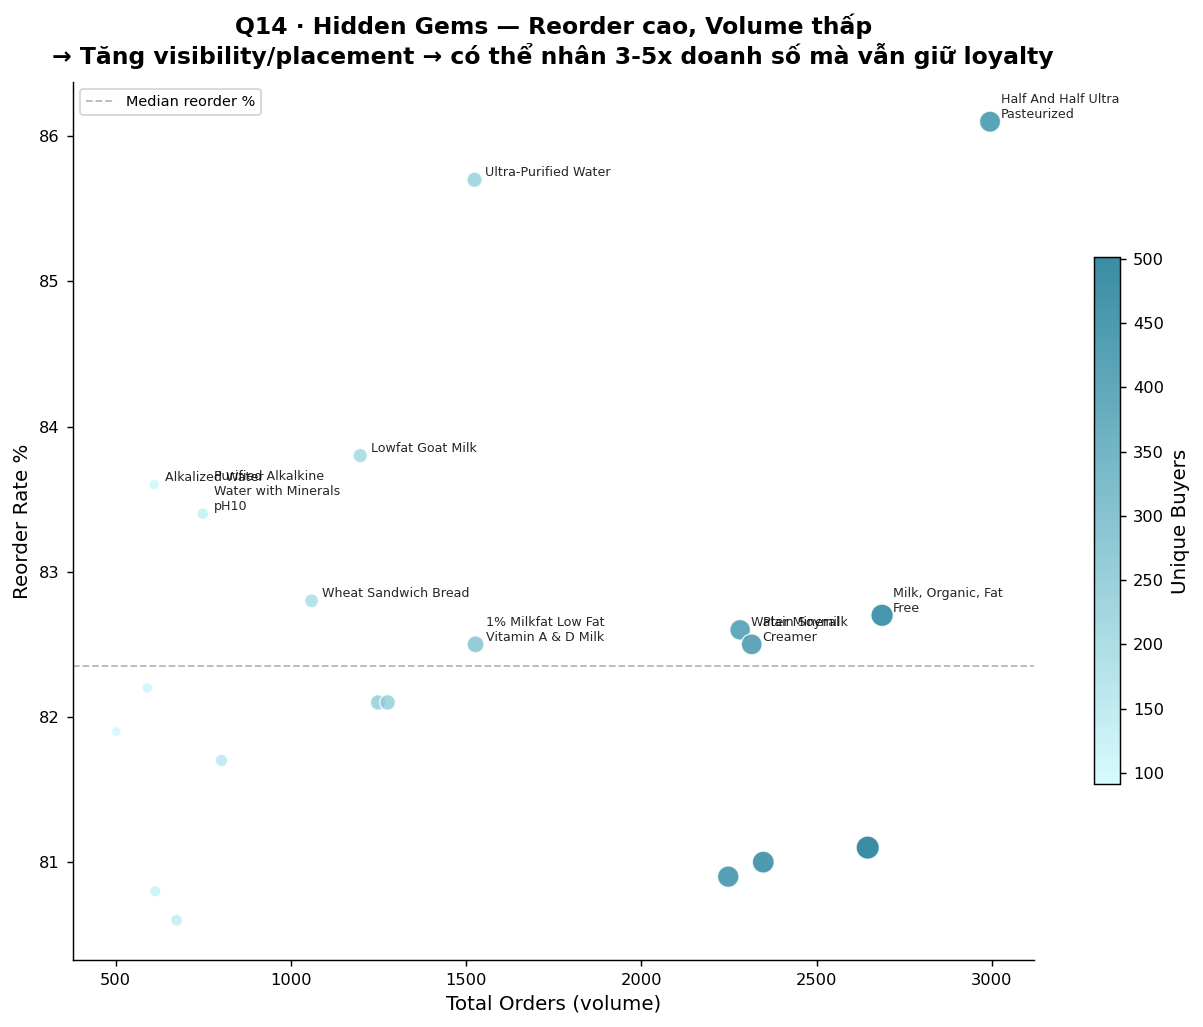

In [42]:
fig, ax = plt.subplots(figsize=(10, 8))

norm_u = plt.Normalize(q14_pd["unique_buyers"].min(), q14_pd["unique_buyers"].max())
cmap_t = LinearSegmentedColormap.from_list("teal", ["#CFFAFE","#0E7490"])
colors = cmap_t(norm_u(q14_pd["unique_buyers"].values))

sc = ax.scatter(q14_pd["total_orders"], q14_pd["reorder_pct"],
                s=q14_pd["unique_buyers"] / 3,
                c=q14_pd["unique_buyers"], cmap=cmap_t,
                alpha=0.82, edgecolors="white", linewidth=0.8, zorder=3)
fig.colorbar(sc, ax=ax, label="Unique Buyers", shrink=0.6)

for _, row in q14_pd.head(10).iterrows():
    ax.annotate(textwrap.fill(row["product_name"], 20),
                (row["total_orders"], row["reorder_pct"]),
                fontsize=7, xytext=(6, 2), textcoords="offset points", alpha=0.85)

ax.set_xlabel("Total Orders (volume)")
ax.set_ylabel("Reorder Rate %")
ax.set_title("Q14 · Hidden Gems — Reorder cao, Volume thấp\n"
             "→ Tăng visibility/placement → có thể nhân 3-5x doanh số mà vẫn giữ loyalty",
             pad=10)
# Reference lines
ax.axhline(q14_pd["reorder_pct"].median(), color=C_GRAY, linestyle="--",
           linewidth=1, alpha=.5, label="Median reorder %")
ax.legend(fontsize=8)
fig.tight_layout()
save_show(fig, "q14_hidden_gems")


### Q15 · Portfolio Efficiency — quy tắc Pareto 80/20 theo Department
**Kỹ thuật:** `CTE` + `PERCENTILE_APPROX` + `SUM(CASE WHEN)` + `NULLIF` + `GROUP BY`

**Insight:** Ở hầu hết department, top 20% SKU tạo ra 60–80% doanh số → cần tập trung assortment vào core SKU.


In [45]:
q15 = spark.sql("""
    WITH sku_stats AS (
        SELECT
            d.department,
            p.product_id,
            COUNT(op.order_id) AS sold
        FROM order_products_all op
        JOIN products    p ON op.product_id    = p.product_id
        JOIN departments d ON p.department_id  = d.department_id
        GROUP BY d.department, p.product_id
    ),
    -- Tính toán trước ngưỡng phân vị 80% (p80) cho từng phòng ban bằng Window Function
    with_percentile AS (
        SELECT
            *,
            percentile_approx(sold, 0.8) OVER (PARTITION BY department) AS dept_p80
        FROM sku_stats
    )
    -- Thực hiện gộp ngoài cùng và tính toán tỷ lệ đóng góp của Top 20% SKU bán chạy nhất
    SELECT
        department,
        COUNT(product_id)                          AS num_skus,
        SUM(sold)                                  AS total_sold,
        ROUND(AVG(sold), 0)                        AS avg_sold_per_sku,
        ROUND(
            SUM(CASE WHEN sold >= dept_p80
                     THEN sold ELSE 0 END)
            * 100.0 / NULLIF(SUM(sold), 0)
        , 1)                                       AS top20pct_sku_share
    FROM with_percentile
    GROUP BY department
    ORDER BY total_sold DESC
""").cache()

# Chuyển đổi dữ liệu sang Pandas và hiển thị kiểm tra
q15_pd = q15.toPandas()
q15_pd.head()

,department,num_skus,total_sold,avg_sold_per_sku,top20pct_sku_share
0,produce,1684,9888378,5872.0,92.4
1,dairy eggs,3449,5631067,1633.0,87.0
2,snacks,6264,3006412,480.0,84.5
3,beverages,4364,2804175,643.0,87.6
4,frozen,4007,2336858,583.0,82.8


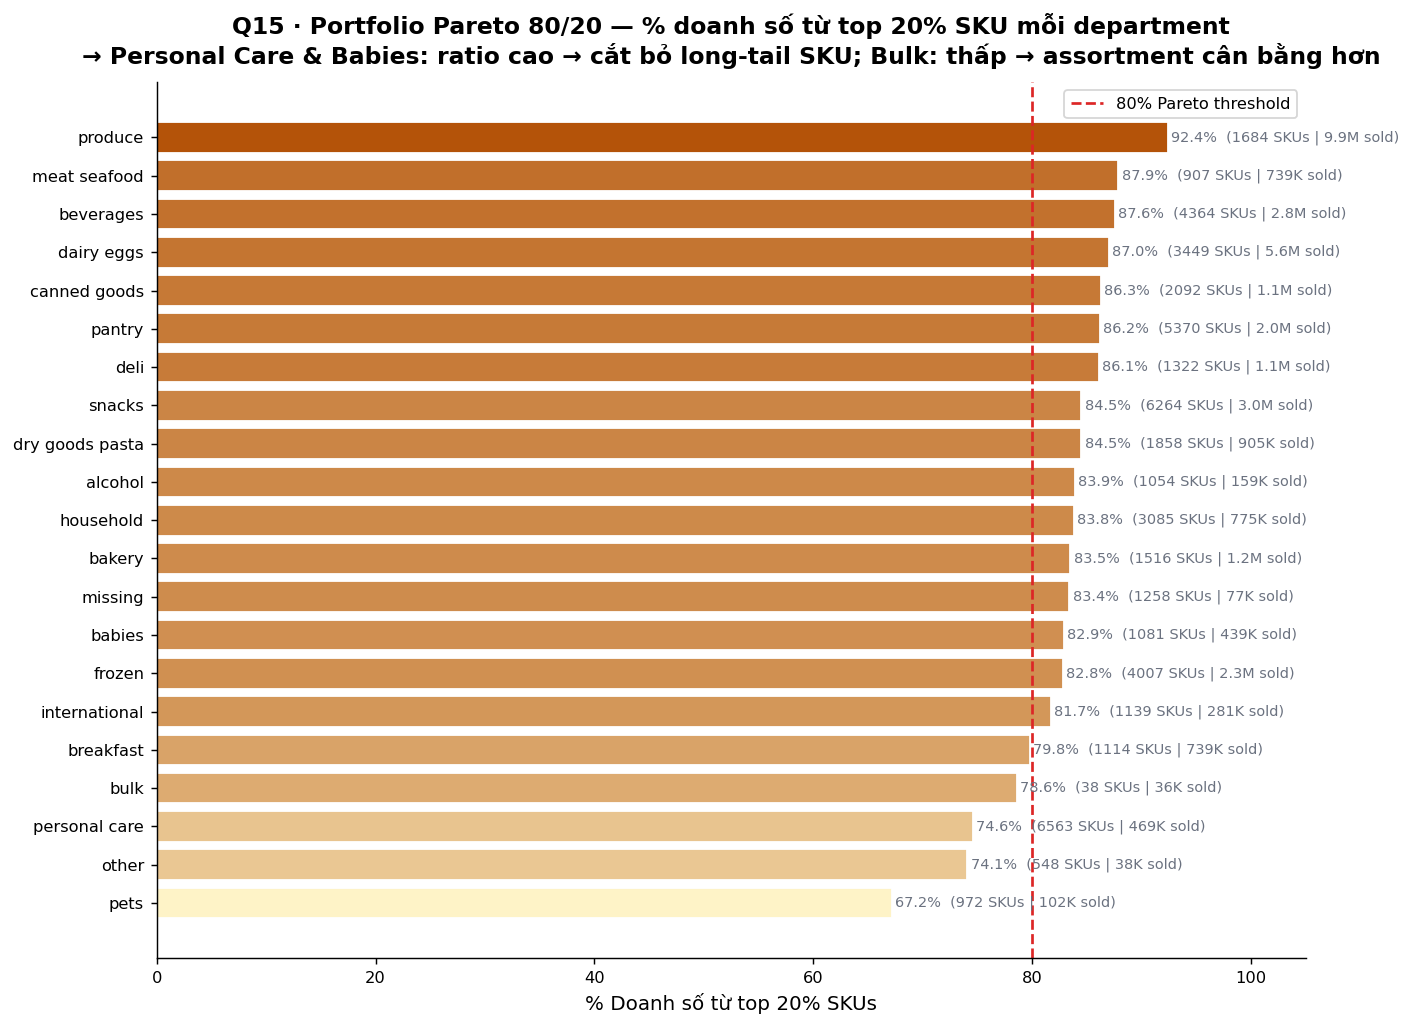

In [47]:
from matplotlib.colors import LinearSegmentedColormap

# 1. KHẮC PHỤC LỖI: Ép kiểu dữ liệu Decimal của Spark sang Float trong Pandas
# Bước này giúp đồng bộ hóa kiểu dữ liệu để Matplotlib thực hiện tính toán chuẩn hóa màu sắc trơn tru.
q15_pd["top20pct_sku_share"] = q15_pd["top20pct_sku_share"].astype(float)
q15_pd["avg_sold_per_sku"] = q15_pd["avg_sold_per_sku"].astype(float)

# 2. Sắp xếp dữ liệu sau khi đã ép kiểu
q15_s = q15_pd.sort_values("top20pct_sku_share", ascending=True)

# 3. Định cấu hình thang màu chuyển sắc tương phản
norm_share = plt.Normalize(q15_s["top20pct_sku_share"].min(),
                           q15_s["top20pct_sku_share"].max())
cmap_pareto = LinearSegmentedColormap.from_list("pr", ["#FEF3C7","#B45309"])
bar_colors  = cmap_pareto(norm_share(q15_s["top20pct_sku_share"].values))

# 4. Khởi tạo và vẽ các thanh bar ngang
fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(q15_s["department"], q15_s["top20pct_sku_share"],
               color=bar_colors, edgecolor="white")

# 5. Thêm nhãn chữ hiển thị giá trị ở đầu mỗi cột
for bar, sku, sold in zip(bars, q15_s["num_skus"], q15_s["total_sold"]):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            # Đổi định dạng từ :.0f thành :.1f để hiển thị đúng độ chính xác 1 chữ số thập phân của câu SQL
            f"{bar.get_width():.1f}%  ({sku} SKUs | {fmt_k(sold, None)} sold)",
            va="center", fontsize=8, color=C_GRAY)

# 6. Cấu hình đường giới hạn Pareto 80% và nhãn trục
ax.axvline(80, color=C_RED, linestyle="--", linewidth=1.5,
           label="80% Pareto threshold")
ax.set_xlabel("% Doanh số từ top 20% SKUs")
ax.set_xlim(0, 105)
ax.legend()
ax.set_title("Q15 · Portfolio Pareto 80/20 — % doanh số từ top 20% SKU mỗi department\n"
             "→ Personal Care & Babies: ratio cao → cắt bỏ long-tail SKU; "
             "Bulk: thấp → assortment cân bằng hơn",
             pad=10)
fig.tight_layout()

# 7. Lưu và hiển thị biểu đồ
save_show(fig, "q15_pareto_portfolio")

---
## 🔬 Bonus — `explain()` : Xem Spark Execution Plan

> `explain()` hiển thị **Physical Plan** mà Spark thực sự thực thi — hữu ích để
> debug performance, kiểm tra join strategy, và xác nhận AQE đã hoạt động.
>
> - `explain()` → Physical Plan tóm tắt  
> - `explain("formatted")` → Plan đầy đủ, dễ đọc hơn  
> - `explain("cost")` → Ước tính row count & cost từng bước


In [44]:
print("=" * 70)
print("📌 Q5 — explain() Physical Plan (Top 20 products, DENSE_RANK Window)")
print("=" * 70)
q5.explain()


📌 Q5 — explain() Physical Plan (Top 20 products, DENSE_RANK Window)
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=true
+- == Final Plan ==
   ResultQueryStage 1
   +- TableCacheQueryStage 0
      +- InMemoryTableScan [product_name#118, department#124, total_sold#967L, reorder_pct#968, rnk#969]
            +- InMemoryRelation [product_name#118, department#124, total_sold#967L, reorder_pct#968, rnk#969], StorageLevel(disk, memory, deserialized, 1 replicas)
                  +- AdaptiveSparkPlan isFinalPlan=true
                  +- == Final Plan ==
                     ResultQueryStage 4
                     +- TakeOrderedAndProject(limit=20, orderBy=[total_sold#967L DESC NULLS LAST], output=[product_name#118,department#124,total_sold#967L,reorder_pct#968,rnk#969])
                        +- *(8) Project [product_name#118, department#124, total_sold#967L, reorder_pct#968, rnk#969]
                           +- Window [dense_rank(_w0#979L) windowspecdefinition(_w0#979L DESC NULLS LAST

In [48]:
print("=" * 70)
print("📌 Q12 — explain('formatted') | Self-JOIN Co-occurrence")
print("=" * 70)
q12.explain("formatted")


📌 Q12 — explain('formatted') | Self-JOIN Co-occurrence
== Physical Plan ==
AdaptiveSparkPlan (115)
+- == Final Plan ==
   ResultQueryStage (114)
   +- TableCacheQueryStage (113), Statistics(sizeInBytes=916.0 B, rowCount=20)
      +- InMemoryTableScan (1)
            +- InMemoryRelation (2)
                  +- AdaptiveSparkPlan (112)
                  +- == Final Plan ==
                     ResultQueryStage (50)
                     +- TakeOrderedAndProject (49)
                        +- * HashAggregate (48)
                           +- ShuffleQueryStage (47), Statistics(sizeInBytes=661.4 KiB, rowCount=8.85E+3)
                              +- Exchange (46)
                                 +- * HashAggregate (45)
                                    +- * Project (44)
                                       +- * BroadcastHashJoin Inner BuildRight (43)
                                          :- * Project (40)
                                          :  +- * BroadcastHashJoin Inner Bu

In [49]:
print("=" * 70)
print("📌 Q15 — explain('cost') | CTE + PERCENTILE_APPROX Pareto")
print("=" * 70)
q15.explain("cost")


📌 Q15 — explain('cost') | CTE + PERCENTILE_APPROX Pareto
== Optimized Logical Plan ==
InMemoryRelation [department#3191, num_skus#3183L, total_sold#3184L, avg_sold_per_sku#3185, top20pct_sku_share#3186], StorageLevel(disk, memory, deserialized, 1 replicas), Statistics(sizeInBytes=926.0 B, rowCount=21)
   +- AdaptiveSparkPlan isFinalPlan=true
      +- == Final Plan ==
         ResultQueryStage 5
         +- *(9) Sort [total_sold#3184L DESC NULLS LAST], true, 0
            +- ShuffleQueryStage 4
               +- Exchange rangepartitioning(total_sold#3184L DESC NULLS LAST, 8), ENSURE_REQUIREMENTS, [plan_id=8108]
                  +- *(8) Project [department#3230, _aggregateexpression#3195L AS num_skus#3183L, _aggregateexpression#3196L AS total_sold#3184L, round(_aggregateexpression#3197, 0) AS avg_sold_per_sku#3185, round(((cast(_aggregateexpression#3199L as decimal(20,0)) * 100.0) / if ((_aggregateexpression#3196L = 0)) null else cast(_aggregateexpression#3196L as decimal(20,0))), 1) AS

In [50]:
print("=" * 70)
print("📌 Q13 — explain('extended') | CTE + Window RANK Partition")
print("   → Xem cả Parsed / Analyzed / Optimized / Physical Plan")
print("=" * 70)
q13.explain("extended")


📌 Q13 — explain('extended') | CTE + Window RANK Partition
   → Xem cả Parsed / Analyzed / Optimized / Physical Plan
== Parsed Logical Plan ==
CTE [dept_slot, ranked]
:  :- 'SubqueryAlias dept_slot
:  :  +- 'Aggregate ['time_slot, 'd.department], [CASE WHEN 'between(cast('o.order_hour_of_day as int), 6, 11) THEN A. 06-11 Sáng WHEN 'between(cast('o.order_hour_of_day as int), 12, 17) THEN B. 12-17 Chiều WHEN 'between(cast('o.order_hour_of_day as int), 18, 21) THEN C. 18-21 Tối ELSE D. 22-05 Đêm END AS time_slot#2563, 'd.department, 'COUNT(1) AS items_sold#2564]
:  :     +- 'Join Inner, ('p.department_id = 'd.department_id)
:  :        :- 'Join Inner, ('op.product_id = 'p.product_id)
:  :        :  :- 'Join Inner, ('o.order_id = 'op.order_id)
:  :        :  :  :- 'SubqueryAlias o
:  :        :  :  :  +- 'UnresolvedRelation [orders], [], false
:  :        :  :  +- 'SubqueryAlias op
:  :        :  :     +- 'UnresolvedRelation [order_products_all], [], false
:  :        :  +- 'SubqueryAlias p

> **Hướng dẫn đọc explain():**
> - **`FileScan`** → Spark đọc file CSV từ đâu
> - **`Filter`** / **`Project`** → Predicate pushdown / column pruning (optimization)
> - **`HashAggregate`** → GROUP BY dùng hash table (nhanh hơn Sort)
> - **`Exchange hashpartitioning`** → shuffle data qua network (tốn kém nhất — giảm thiểu)
> - **`Sort`** / **`Window`** → Window function yêu cầu sort trước
> - **`BroadcastHashJoin`** → Spark tự broadcast bảng nhỏ (aisles, departments) → rất hiệu quả
> - **`SortMergeJoin`** → Join hai bảng lớn (order_products) — xuất hiện khi cả hai bảng đều lớn


In [ ]:
# Wrap up
print("✅ Hoàn thành 15 queries + visualizations + explain()")
print("   Dashboards saved tại /kaggle/working/q*.png")
